# Function 2

This function is described by 2 input features, each of which are normalised to lie within the range 0 and 1. The optimisation goal is to maximise the output value. The function describes the log-likelihood score of two machine learning model parameters. The machine learning model is unknown. The initial data set consists of 10 data points.

## Summary

There appears to be a region containing many maxima between 0.6 < `x0` < 0.8, which is not very sensitive to changes in `x1`. The most promising method developed has been to use a decision tree model to divide the landscape into regions that correspond to the model's leaf nodes. Then to randomly generate a number of candidates in each of these regions, where more points are generated in regions with data points that give higher mean outputs. The data is fit to a global Gaussian Process surrogate model as there are not enough points to train local models in each region, and each candidate is assessed according to an acquisition function such as Expected Improvement (EI).

## Week 1 - Initial exploration

In [1]:
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF

from bbo.data import get_current_weeks_points
from bbo.plotting import plot_2d_gp_surfaces
from bbo.random import create_rng_seed
from bbo.utils import construct_meshgrid, get_farthest_point

seed_input = "function 2"  # input string to create random seed
n_dimensions = 2  # number of features
grd_res = 1001  # axis resolution

In [2]:
X, y = get_current_weeks_points(function_id=2, week=1)

print(f"Mean = {y.mean()}")
print(f"Standard deviation = {y.std()}")

print(f"Minimum = {y.min()}")
quantiles = [0.25, 0.5, 0.75]
for quantile in quantiles:
    print(f"{quantile * 100}% quantile = {np.quantile(y, quantile)}")
print(f"Maximum = {y.max()}")

Mean = 0.23067376631994235
Standard deviation = 0.22536450367310826
Minimum = -0.06562362443733738
25.0% quantile = 0.02701641613768254
50.0% quantile = 0.22979192705246562
75.0% quantile = 0.38893790782370347
Maximum = 0.6112052157614438


Initial exploratory data analysis reveals a handful of points with negative values. However, the absolute magnitude of the negative outputs is an order of magnitude smaller than that of the best observed point. Therefore, while we could set these values to zero, they should have little effect on the analysis and therefore there is no need to change them.

The mean and median are fairly close to each other implying that the outputs are fairly evenly distributed. Additionally, the standard deviation is comparable to the mean, indicating that there is a relatively large range in output values.

As there are a relatively small number of observed data points and given the limited number of queries we can submit, we apply Bayesian Optimisation. We fit a Gaussian Process surrogate model to the data, allowing us to model the underlying function and its associated uncertainty. A Radial Basis Function (RBF) kernel is chosen initially, and it is assumed at this stage that both features are of equal importance and therefore the length scales are fixed at 0.1.

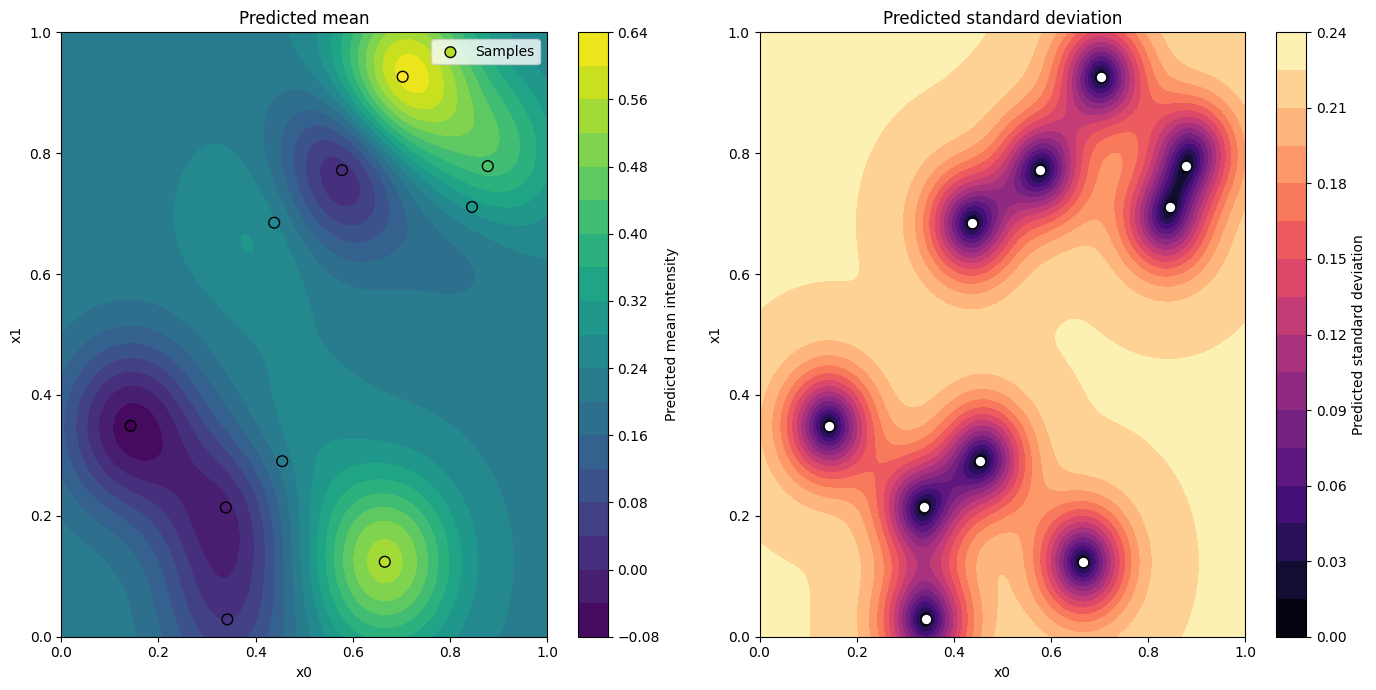

In [3]:
# Fit Gaussian Process surrogate model on known data
kernel = RBF(length_scale=[0.1, 0.1], length_scale_bounds='fixed')
model = GaussianProcessRegressor(
    kernel=kernel, n_restarts_optimizer=10, normalize_y=True, random_state=create_rng_seed(seed_input)
)
model.fit(X, y)

# Perform grid search to evaluate model output
X0, X1 = construct_meshgrid(n_dimensions=n_dimensions, grd_res=grd_res)
X_pred = np.column_stack([X0.ravel(), X1.ravel()])
y_mean, y_std = model.predict(X_pred, return_std=True)
Y_mean = y_mean.reshape(grd_res, grd_res)
Y_std = y_std.reshape(grd_res, grd_res)

# Plot predicted means and standard deviations
fig, axs = plot_2d_gp_surfaces(
    X0=X0, X1=X1, Y_mean=Y_mean, Y_std=Y_std, x_samples=X, y_samples=y
)

From the countour plot there appear to be two promising regions: around (0.7, 0.95); and around (0.65, 0.1). It may be worth exploiting these areas, or exploring in their vicinity in the future. If there are two promising regions, there may be more, so we can afford to dedicate the first few queries to a phase of exploration.

We can do this by ignoring the mean and performing a grid search to find the point with the highest standard deviation:

In [4]:
# Use standard deviation as acquisition function for pure exploration
max_idx = np.unravel_index(np.argmax(Y_std), Y_std.shape)
x_next = np.array([X0[max_idx], X1[max_idx]])
print(f"Proposed point using pure exploration acquisition function = {x_next}")

Proposed point using pure exploration acquisition function = [0. 1.]


The proposed point lies in one of the corners, and little information would be gained here. We could move a bit closer to the centre and query the point (0.05, 0.95).

Alternatively, as we are in the exploration phase, and there is very little data to work with, we could query the point that lies farthest from any observed data points and corners:

In [5]:
# Find farthest point on grid from any corners or samples
x_next = get_farthest_point(X, n_dimensions, grd_res)
print(f"Farthest point on grid from any corners or samples = {x_next}")

Farthest point on grid from any corners or samples = [0.999 0.372]


While the above point lies near a boundary, it should provide more information than a point lying near a corner.

## Week 2 - Investigating a promising region

In [6]:
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF

from bbo import acquisition
from bbo.data import get_current_weeks_points
from bbo.plotting import plot_2d_gp_surfaces
from bbo.utils import construct_meshgrid

seed_input = "function 2"  # input string to create random seed
n_dimensions = 2  # number of features
grd_res = 1001  # axis resolution

In [7]:
X, y = get_current_weeks_points(function_id=2, week=2)

print(f"Last week's query {X[-1]} yields {y[-1]}")

Last week's query [0.999 0.372] yields -0.045574833281322634


Last week's query yields a negative output. This helps us to exclude a region of phase space.

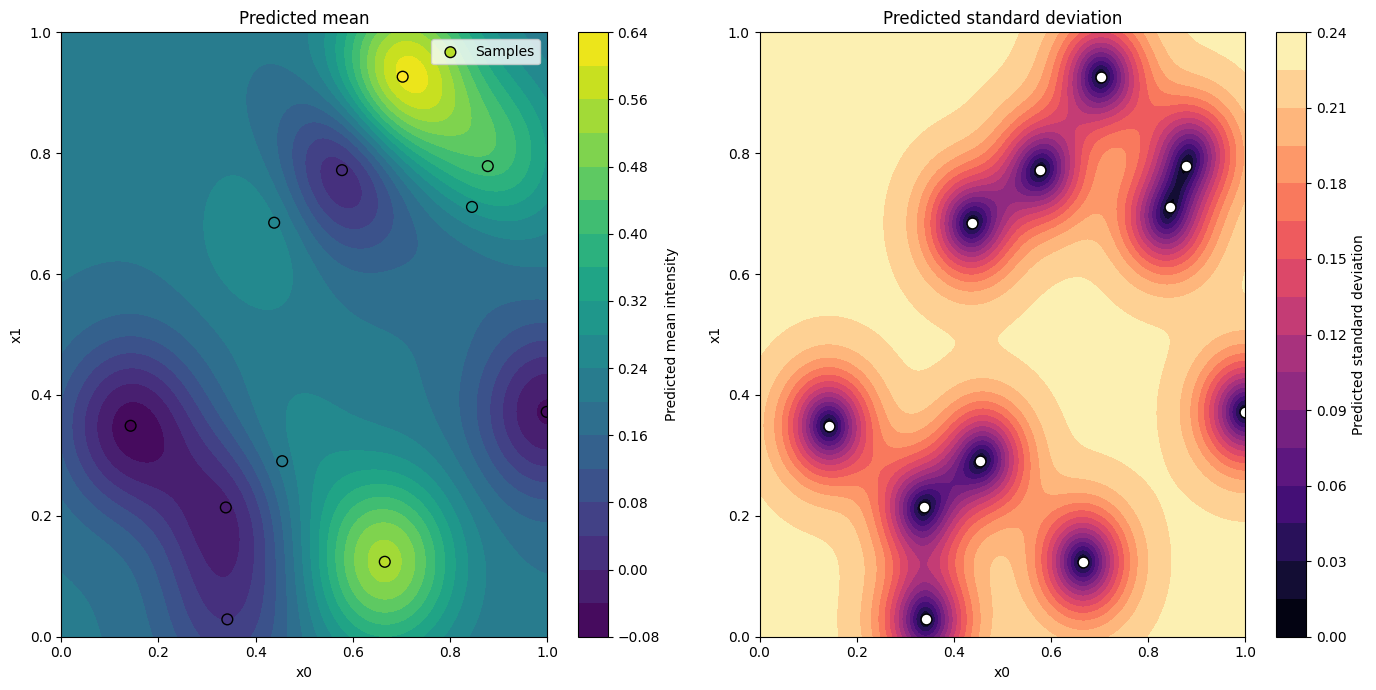

In [8]:
# Fit Gaussian Process surrogate model on known data
kernel = RBF(length_scale=[0.1, 0.1], length_scale_bounds='fixed')
model = GaussianProcessRegressor(
    kernel=kernel, n_restarts_optimizer=10, normalize_y=True, random_state=create_rng_seed(seed_input)
)
model.fit(X, y)

# Perform grid search to evaluate model output
X0, X1 = construct_meshgrid(n_dimensions=n_dimensions, grd_res=grd_res)
X_pred = np.column_stack([X0.ravel(), X1.ravel()])
y_mean, y_std = model.predict(X_pred, return_std=True)
Y_mean = y_mean.reshape(grd_res, grd_res)
Y_std = y_std.reshape(grd_res, grd_res)

# Plot predicted means and standard deviations
fig, axs = plot_2d_gp_surfaces(
    X0=X0, X1=X1, Y_mean=Y_mean, Y_std=Y_std, x_samples=X, y_samples=y
)

We have two possibilities: either we query a point in the top left region (i.e. low `x0`, high `x1`); or we can use the Upper Confidence Bound (UCB) acqusition function to find a point near one of the suspected maxima. As we have two promising regions and a limited evaluation budget, it would be better to explore around these areas first. We can then explore other regions, such as the top left, if we have any queries remaining.

In [9]:
# Use Upper Confidence Bound (UCB) acquisition function with k = 1.96 (95% confidence interval)
max_idx = np.unravel_index(np.argmax(acquisition.ucb(Y_mean, Y_std, k=1.96)), Y_mean.shape)
x_next = np.array([X0[max_idx], X1[max_idx]])
print(f"Proposed point using Upper Confidence Bound (k = 1.96) acquisition function = {x_next}")

Proposed point using Upper Confidence Bound (k = 1.96) acquisition function = [0.798 0.914]


## Week 3 - Mapping out a suspected peak

In [10]:
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF

from bbo import acquisition
from bbo.data import get_current_weeks_points
from bbo.plotting import plot_2d_gp_surfaces
from bbo.utils import construct_meshgrid

seed_input = "function 2"  # input string to create random seed
n_dimensions = 2  # number of features
grd_res = 1001  # axis resolution

In [11]:
X, y = get_current_weeks_points(function_id=2, week=3)

print(f"Last week's query {X[-1]} yields {y[-1]}")

Last week's query [0.798 0.914] yields 0.028222579790449585


Last week's query explored part of the region close to the best observed point. While positive, the output value is quite low, implying that the suspected peak may not be smooth.

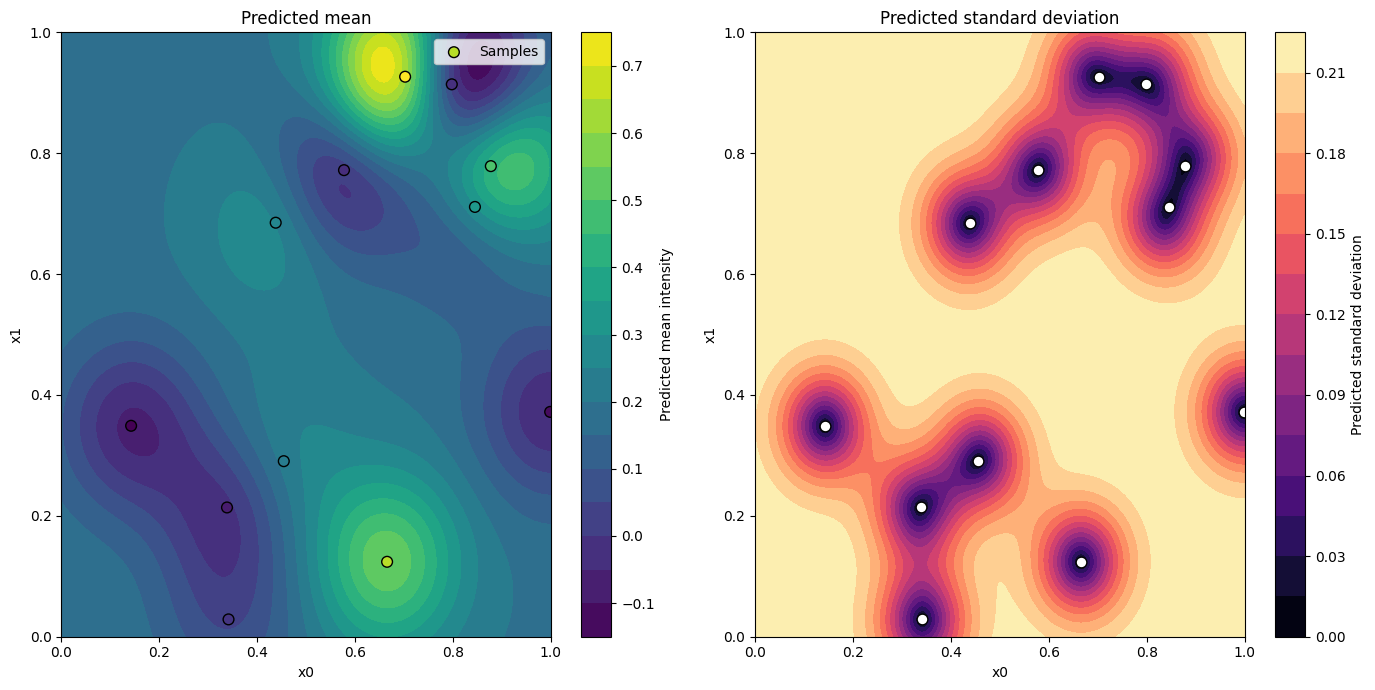

In [12]:
# Fit Gaussian Process surrogate model on known data
kernel = RBF(length_scale=[0.1, 0.1], length_scale_bounds='fixed')
model = GaussianProcessRegressor(
    kernel=kernel, n_restarts_optimizer=10, normalize_y=True, random_state=create_rng_seed(seed_input)
)
model.fit(X, y)

# Perform grid search to evaluate model output
X0, X1 = construct_meshgrid(n_dimensions=n_dimensions, grd_res=grd_res)
X_pred = np.column_stack([X0.ravel(), X1.ravel()])
y_mean, y_std = model.predict(X_pred, return_std=True)
Y_mean = y_mean.reshape(grd_res, grd_res)
Y_std = y_std.reshape(grd_res, grd_res)

# Plot predicted means and standard deviations
fig, axs = plot_2d_gp_surfaces(
    X0=X0, X1=X1, Y_mean=Y_mean, Y_std=Y_std, x_samples=X, y_samples=y
)

In [13]:
# Use Upper Confidence Bound (UCB) acquisition function with k = 1.96 (95% confidence interval)
max_idx = np.unravel_index(np.argmax(acquisition.ucb(Y_mean, Y_std, k=1.96)), Y_mean.shape)
x_next = np.array([X0[max_idx], X1[max_idx]])
print(f"Proposed point using Upper Confidence Bound (k = 1.96) acquisition function = {x_next}")
print(f"Distance between proposed point and best point = {np.linalg.norm(X[np.argmax(y)] - x_next)}")
print(f"Distance between best point and last week's query = {np.linalg.norm(X[np.argmax(y)] - X[-1])}")

Proposed point using Upper Confidence Bound (k = 1.96) acquisition function = [0.63  0.978]
Distance between proposed point and best point = 0.08900399528094197
Distance between best point and last week's query = 0.0961875529119504


The Upper Confidence Bond acquistion function proposes a point a bit closer to the best observed point than last week's query. It is still worth investigating as it could potentially provide information on the steepness of the peak.

## Week 4 - Attempting to fit linear regression models

In [14]:
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF

from bbo import acquisition
from bbo.data import get_current_weeks_points
from bbo.linear_regression import get_lr_models, kfoldcv, loocv
from bbo.plotting import plot_2d_gp_surfaces, plot_correlation_matrix
from bbo.stats import get_baseline_rmse, get_baseline_mse
from bbo.utils import construct_meshgrid, grid_search

seed_input = "function 2"  # input string to create random seed
n_dimensions = 2  # number of features
grd_res = 1001  # axis resolution

In [15]:
X, y = get_current_weeks_points(function_id=2, week=4)

print(f"Last week's query {X[-1]} yields {y[-1]}")

Last week's query [0.63  0.978] yields 0.3110491429257078


Last week's query yields an output around half that of the best observed point. In future, it may be worth using a more exploitative acquisition function such as Probability of Improvement (PI) or decreasing the exploration parameter `k`. This would help to find the peak in this region.

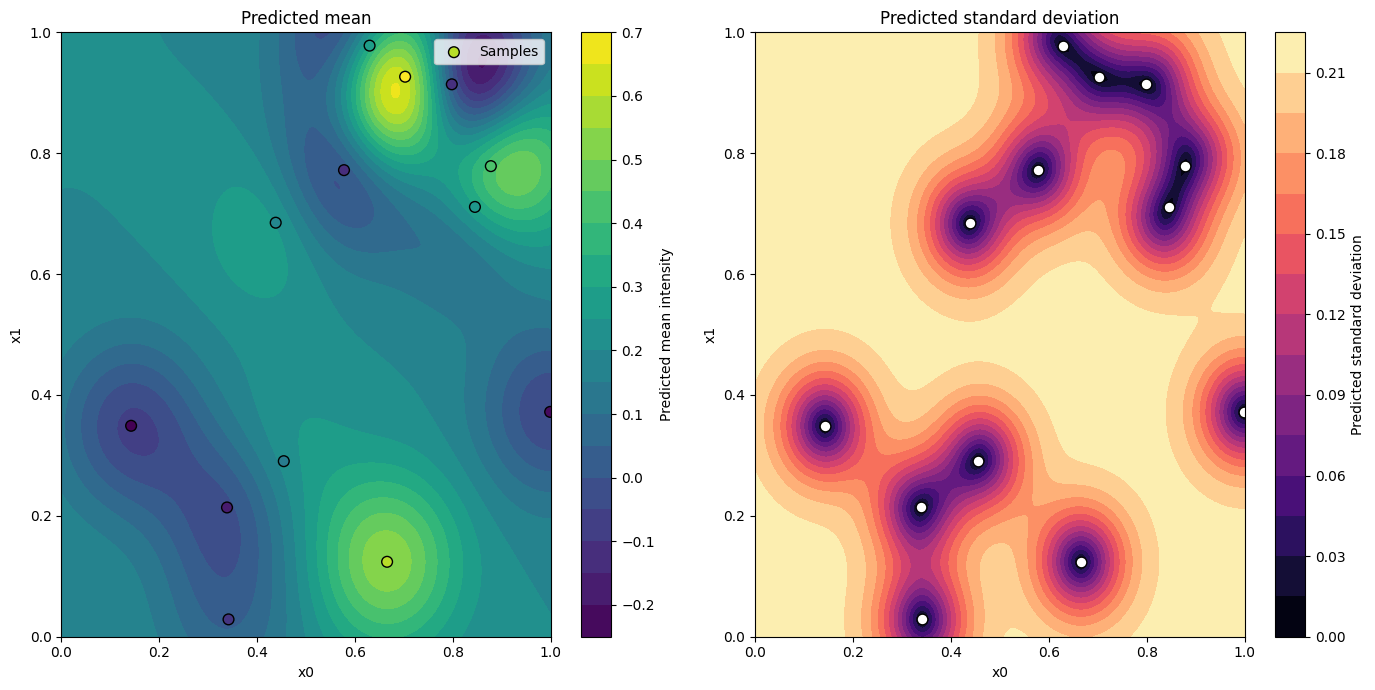

In [16]:
# Fit Gaussian Process surrogate model on known data
kernel = RBF(length_scale=[0.1, 0.1], length_scale_bounds='fixed')
model = GaussianProcessRegressor(
    kernel=kernel, n_restarts_optimizer=10, normalize_y=True, random_state=create_rng_seed(seed_input)
)
model.fit(X, y)

# Perform grid search to evaluate model output
X0, X1 = construct_meshgrid(n_dimensions=n_dimensions, grd_res=grd_res)
X_pred = np.column_stack([X0.ravel(), X1.ravel()])
y_mean, y_std = model.predict(X_pred, return_std=True)
Y_mean = y_mean.reshape(grd_res, grd_res)
Y_std = y_std.reshape(grd_res, grd_res)

# Plot predicted means and standard deviations
fig, axs = plot_2d_gp_surfaces(
    X0=X0, X1=X1, Y_mean=Y_mean, Y_std=Y_std, x_samples=X, y_samples=y
)

In [17]:
# Use Upper Confidence Bound (UCB) acquisition function with k = 1.96 (95% confidence interval)
max_idx = np.unravel_index(np.argmax(acquisition.ucb(Y_mean, Y_std, k=1.96)), Y_mean.shape)
x_next = np.array([X0[max_idx], X1[max_idx]])
print(f"Proposed point using Upper Confidence Bound (k = 1.96) acquisition function = {x_next}")
print(f"Distance between proposed point and best point = {np.linalg.norm(X[np.argmax(y)] - x_next)}")

Proposed point using Upper Confidence Bound (k = 1.96) acquisition function = [0.678 0.873]
Distance between proposed point and best point = 0.05895831744368812


The Upper Confidence Bound (UCB) acquisition function suggests another point in this region that is worth exploring. However, before we commit to it, we can explore whether a linear regression model could describe the underlying data.

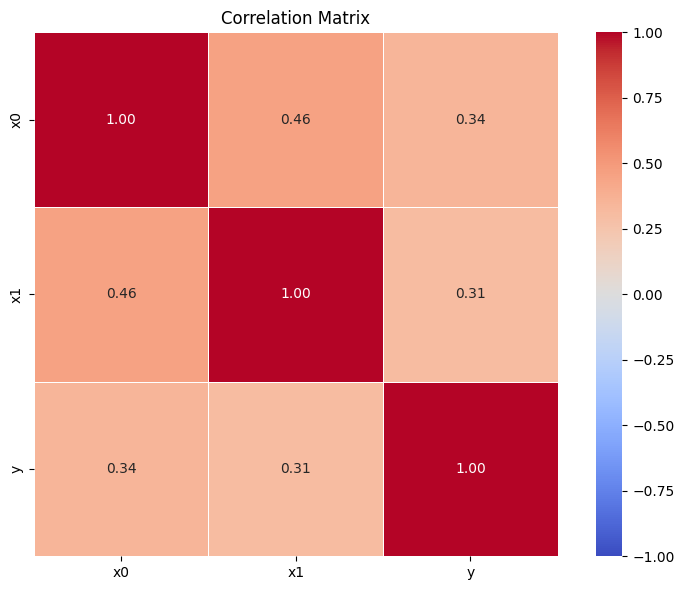

In [18]:
fig, ax = plot_correlation_matrix(X, y)

There is no strong correlation between the inputs and the output. Inputs `x0` and `x1` may be moderately correlated, but there are too few observered data points to reach any sort of conclusion.

In [19]:
print(f"Baseline RMSE = {get_baseline_rmse(y)}")

cv_methods = {
    "Leave One Out Cross Validation": loocv(X, y),
    "5-Fold Cross Validation": kfoldcv(X, y, seed_input=seed_input, n_splits=5),
}
for method, scores in cv_methods.items():
    print(f"\n{method}")
    for name, stats in scores.items():
        print(f"{name} model: RMSE = {stats['RMSE']}, RMSE spread = {stats['RMSE spread']}, relative RMSE = {stats['relative RMSE']}")

Baseline RMSE = 0.21828823094785185

Leave One Out Cross Validation
linear model: RMSE = 0.2869420623092194, RMSE spread = 0.18099244020244443, relative RMSE = 0.42395070255124767
quadratic model: RMSE = 0.4161211903725306, RMSE spread = 0.2575714792933941, relative RMSE = 0.61481007554335
cubic model: RMSE = 0.6798458837112369, RMSE spread = 0.49688990870305355, relative RMSE = 1.0044576166576613

5-Fold Cross Validation
linear model: RMSE = 0.24354772003876687, RMSE spread = 0.11762477404288349, relative RMSE = 0.359836498644529
quadratic model: RMSE = 0.4435589352600317, RMSE spread = 0.13429843811679584, relative RMSE = 0.6553487512880815
cubic model: RMSE = 33.41902626035521, RMSE spread = 2.9696062631626567, relative RMSE = 49.37588984910899


We perform leave one out and 5-fold cross-validations, and compare the Root Mean Square Errors (RMSE). The baseline RMSE is calculated using the mean as the predicted value for all observations. None of the models perform better than the baseline RMSE within errors, implying that they would add little value.

Given that we only have 14 observed data points, this is not unexpected in the quadratic and cubic models. The latter has 10 parameters, which is comparable with the number of data points, implying that it would be prone to overfitting. As there is no strong correlation between any of the inputs and the output, the linear model also does not perform well.

So far, we have been performing grid searches to identify points that yield the highest value for the UCB acquisition function. We can improve the resolution of these searches by zooming in on an identified point and then conducting another grid search. We can repeat this until we reach a resolution in the order of 1e-6, whcih is equivalent to the maximum number of decimal places that can be given to the inputs when submitting queries.

This is unnecessarily precise, as the differences in outputs at these scales are likely to negligible. However, at higher dimensions we have to use sparser grids, and therefore can be useful.

Better regions that warrant investigation can be masked by only zooming in on the best point. This becomes more of an issue when using sparser grids at higher dimensions.

In [20]:
x_next = grid_search(model, acq_func=acquisition.ucb, k=1.96, n_dimensions=2, grd_res=grd_res)
print(f"Proposed point using Upper Confidence Bound (k = 1.96) acquisition function = {x_next}")

Proposed point using Upper Confidence Bound (k = 1.96) acquisition function = [0.67816608 0.87316608]


## Week 5 - Investigating the influence of `x1`

In [21]:
import numpy as np

from bbo import acquisition
from bbo.bayesian_optimisation import get_reg_model
from bbo.data import get_current_weeks_points
from bbo.plotting import plot_2d_gp_surfaces
from bbo.utils import construct_meshgrid, grid_search

seed_input = "function 2"  # input string to create random seed
n_dimensions = 2  # number of features
grd_res = 1001  # axis resolution

In [22]:
X, y = get_current_weeks_points(function_id=2, week=5)

print(f"Last week's query {X[-1]} yields {y[-1]}")

Last week's query [0.678471 0.872835] yields 0.5604928662282773


Last week's query has an output that is relatvely close to that of the best observed point.

So far, we have assumed that both input features contribute identically to the underlying function. We can test this by leaving the length scales free to vary between bounds when fitting the Gaussian Process surrogate model:

Length scales: x0 = 0.04658891615550058, x1 = 1.5560652518615523


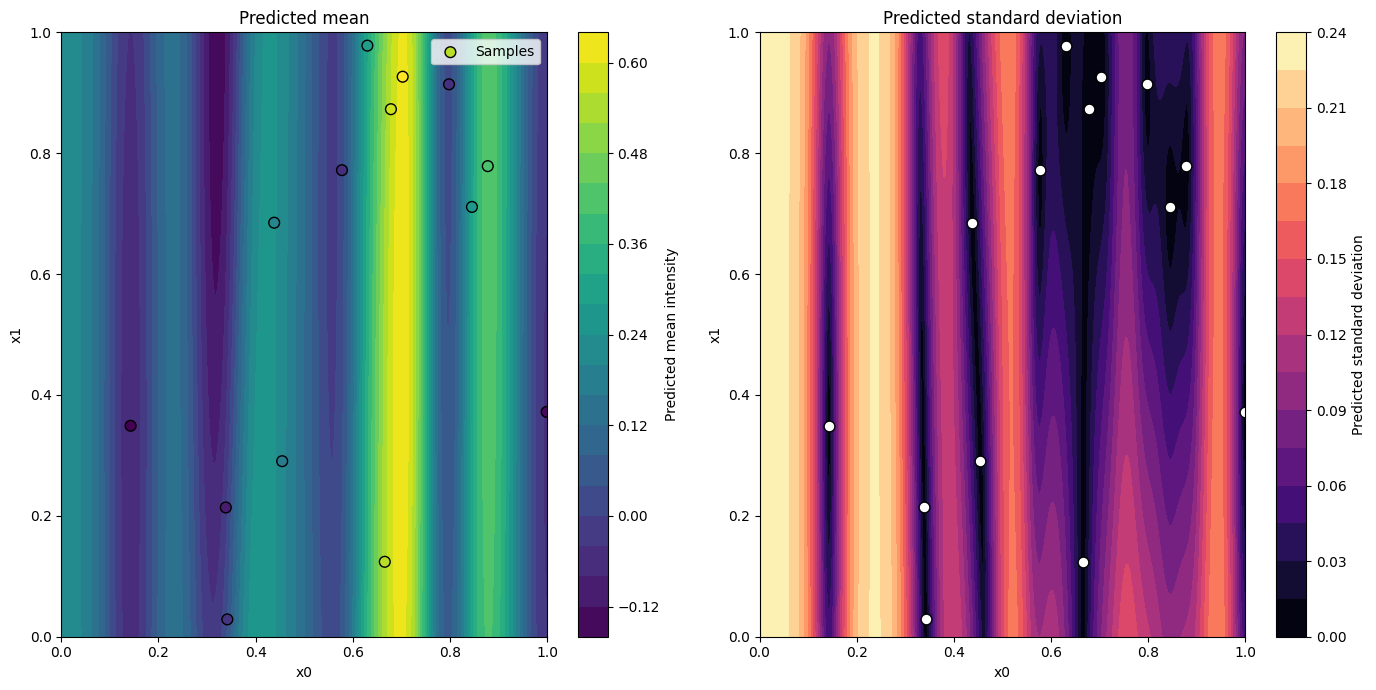

In [23]:
# Fit Gaussian Process surrogate model on known data
model = get_reg_model(
    n_dimensions=2, seed_input=seed_input, length_scale_bounds=(1e-2, 10)
)
model.fit(X, y)

length_scales = model.kernel_.length_scale
print(f"Length scales: x0 = {length_scales[0]}, x1 = {length_scales[1]}")

# Perform grid search to evaluate model output
X0, X1 = construct_meshgrid(n_dimensions=n_dimensions, grd_res=grd_res)
X_pred = np.column_stack([X0.ravel(), X1.ravel()])
y_mean, y_std = model.predict(X_pred, return_std=True)
Y_mean = y_mean.reshape(grd_res, grd_res)
Y_std = y_std.reshape(grd_res, grd_res)

# Plot predicted means and standard deviations
fig, axs = plot_2d_gp_surfaces(
    X0=X0, X1=X1, Y_mean=Y_mean, Y_std=Y_std, x_samples=X, y_samples=y
)

It looks as though the input `x1` has little affect on the underlying function. There are a couple of caveats to this conclusion: firstly, there are not enough observed data points to make such a claim with certainty, and we simply do not have enough queries to test this; and secondly, we are using a Radial Basis Function (RBF) kernel, which assumes that the underlying function is smooth.

There appear to be two promising regions: at around `x0` = 0.7 and `x0` = 0.9. The former region is the more promising at the moment, so should be the priority for investigation. The Upper Confidence Bound (UCB) acquisition function suggests a point in this region close to the `x1` = 0 boundary. It would be interesting to see whether we get a comparably high output when querying this point, as it would prvide futher evidence that the underlying function is less sensitive to changes in `x1`.

There is, of course, still the possibility that we are dealing with two maxima in this promising region as opposed to a single, broad peak.

In [24]:
# Perform grid search staying away from boundaries
x_next = grid_search(
    model,
    acq_func=acquisition.ucb,
    k=1.96,
    n_dimensions=2,
    grd_res=grd_res,
    bounds=[(0.002, 0.998), (0.002, 0.998)],
)
print(f"Proposed point using Upper Confidence Bound (k = 1.96) acquisition function = {x_next}")

Proposed point using Upper Confidence Bound (k = 1.96) acquisition function = [0.7099558 0.002    ]


## Week 6 - Resolving potential maxima

In [25]:
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF

from bbo import acquisition
from bbo.bayesian_optimisation import get_reg_model
from bbo.data import get_current_weeks_points
from bbo.plotting import plot_1d_gp_ucb, plot_2d_gp_surfaces
from bbo.random import create_rng_seed
from bbo.utils import construct_meshgrid, grid_search

seed_input = "function 2"  # input string to create random seed
n_dimensions = 2  # number of features
grd_res = 1001  # axis resolution

In [26]:
X, y = get_current_weeks_points(function_id=2, week=6)

print(f"Last week's query {X[-1]} yields {y[-1]}")

Last week's query [0.709956 0.002   ] yields 0.57860251197845


This is an interesting result. Last week's point gives an output value comparable with the best observed value. While it cannot be said with certainty that `x1` is irrelevant, this result does encourage us to take a look a closer look in this region to determine whether this is a single, broad peak or two or more maxima.

Length scales: x0 = 0.047618872609612395, x1 = 1.953357656361259


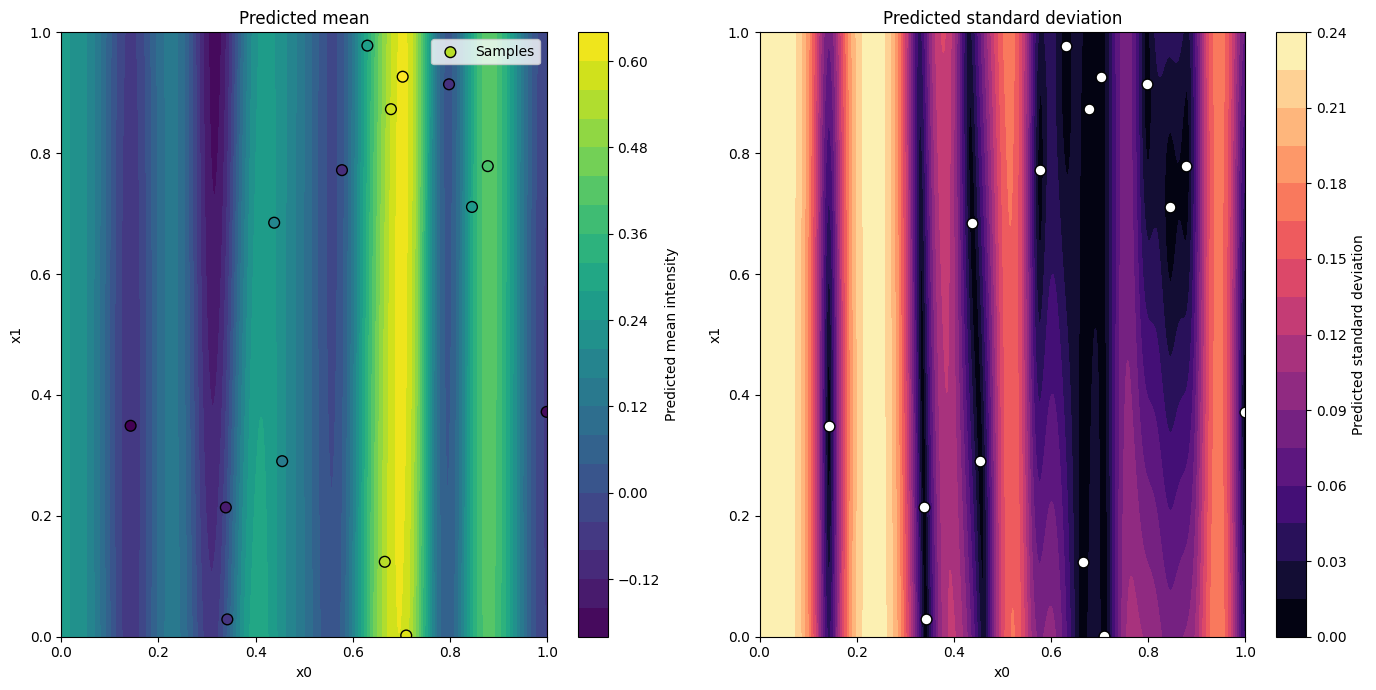

In [27]:
# Fit Gaussian Process surrogate model on known data
model = get_reg_model(
    n_dimensions=2, seed_input=seed_input, length_scale_bounds=(1e-2, 10)
)
model.fit(X, y)

length_scales = model.kernel_.length_scale
print(f"Length scales: x0 = {length_scales[0]}, x1 = {length_scales[1]}")

# Perform grid search to evaluate model output
X0, X1 = construct_meshgrid(n_dimensions=n_dimensions, grd_res=grd_res)
X_pred = np.column_stack([X0.ravel(), X1.ravel()])
y_mean, y_std = model.predict(X_pred, return_std=True)
Y_mean = y_mean.reshape(grd_res, grd_res)
Y_std = y_std.reshape(grd_res, grd_res)

# Plot predicted means and standard deviations
fig, axs = plot_2d_gp_surfaces(
    X0=X0, X1=X1, Y_mean=Y_mean, Y_std=Y_std, x_samples=X, y_samples=y
)

There is not much change in the output of the Gaussian Process surrogate model. The length scale for `x1` has increased by around 25%, but we would expect an increase given last week's result.

If we work under the assumption that `x1` is irrelevant, given the caveats mentioned last week, we can project the data on to the `x0` axis and try to fit to a 1D Gaussian Process surrogate model. This would give us an idea of shape of any peaks in this dimension and would also suggest new regions to explore.

Length scale: x0 = 0.027451422161387313


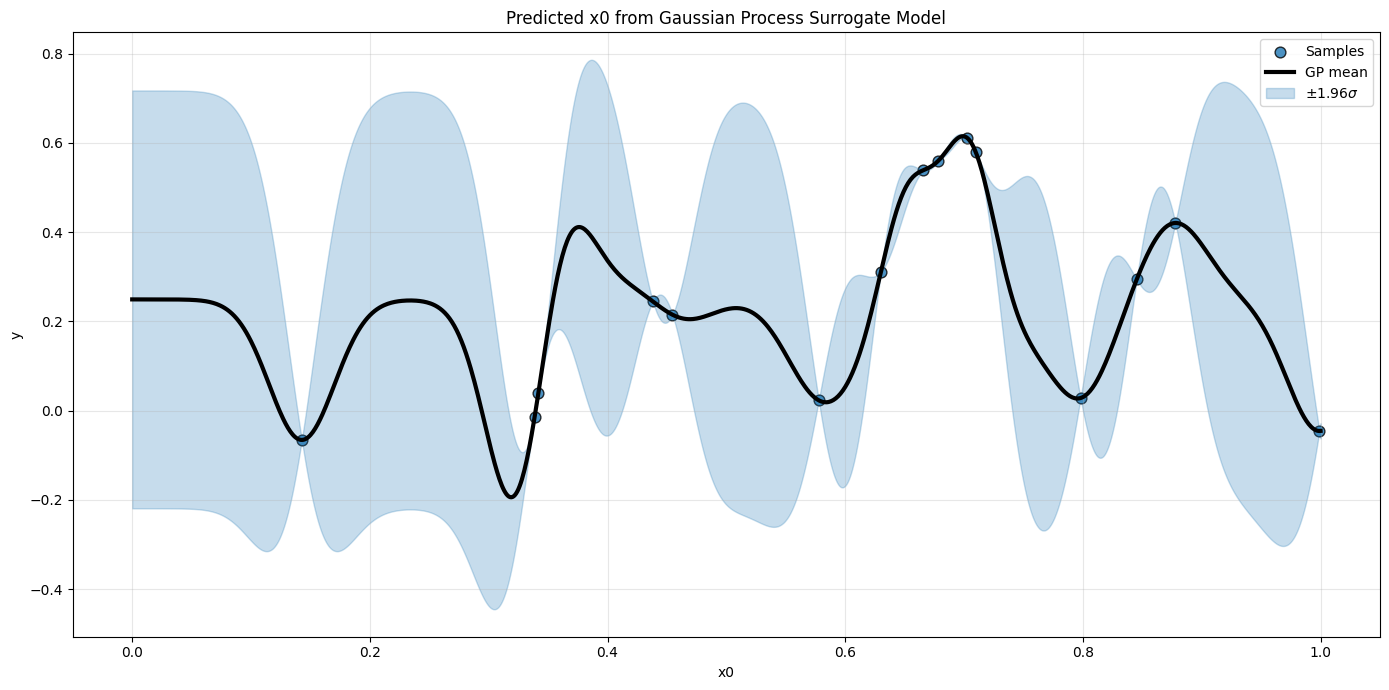

In [28]:
# Fit Gaussian Process surrogate model on x0
kernel = RBF(length_scale=[0.1], length_scale_bounds=(1e-2, 1))
model = GaussianProcessRegressor(
    kernel=kernel,
    n_restarts_optimizer=10,
    normalize_y=True,
    random_state=create_rng_seed(seed_input),
)
# Effectively assume x1 is irrelevant and project all data onto x0 axis
model.fit(X[:, 0].reshape(-1, 1), y)

length_scale = model.kernel_.length_scale
print(f"Length scale: x0 = {length_scale}")

x_pred = np.linspace(0, 1, grd_res)
y_mean, y_std = model.predict(x_pred.reshape(-1, 1), return_std=True)

# Plot predicted means and standard deviations
fig, ax = plot_1d_gp_ucb(
    x_samples=X[:, 0],
    y_samples=y,
    x_pred=x_pred,
    y_mean=y_mean,
    y_std=y_std,
    k=1.96,
    x_label="x0",
)

There are a few things to note here:

Firstly, there are a few promising regions where the model is less certain, that could warrant further exploration if we had a larger budget. Of these, `x0` = 0.9 seems the most promising as we may be approaching a peak here.

However, if there is a peak here, it looks unlikely that it would be larger than the one in the region `x0` = 0.7. By taking the mean `x0` and `x1` values of the four points in this region (which just so happen to be the best 4 observed points), we can get an idea of whether `x1` has a small effect in this region.

In [29]:
# Find centroid of best 4 points
high_idx = np.argsort(y)[:-5:-1]
x_next = np.mean(X[high_idx], axis=0)
print(f"Proposed point from centroid of top 4 points = {x_next}")

Proposed point from centroid of top 4 points = [0.68921578 0.48134208]


## Week 7 - Introducing decision tree ensemble surrogate models

In [30]:
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF

from bbo import acquisition, decision_trees
from bbo.bayesian_optimisation import get_reg_model
from bbo.clustering import get_agglomerative_clusterer
from bbo.data import get_current_weeks_points
from bbo.plotting import plot_1d_gp_ucb, plot_2d_gp_surfaces, plot_decision_tree
from bbo.random import create_rng_seed
from bbo.utils import construct_meshgrid, grid_search_mean

seed_input = "function 2"  # input string to create random seed
n_dimensions = 2  # number of features
grd_res = 1001  # axis resolution

In [31]:
X, y = get_current_weeks_points(function_id=2, week=7)

print(f"Last week's query {X[-1]} yields {y[-1]}")

Last week's query [0.689216 0.481342] yields 0.6086974926214477


Last week's query gives us an output that is the closest so far to that of the best obseved point. It appears as though this narrow band in `x0` is very promising, and warrants further investigation.

Length scales: x0 = 0.051378961284912344, x1 = 2.0622855583062383


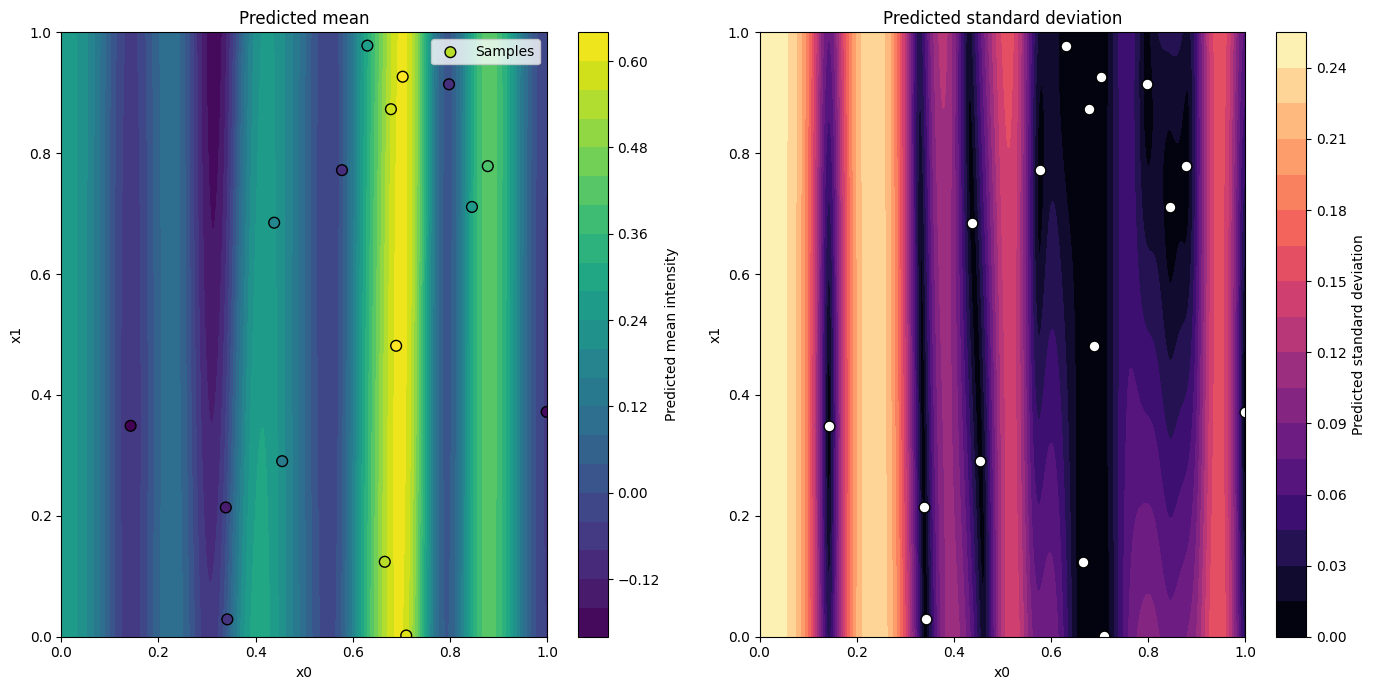

In [32]:
# Fit Gaussian Process surrogate model on known data
model = get_reg_model(
    n_dimensions=2, seed_input=seed_input, length_scale_bounds=(1e-2, 10)
)
model.fit(X, y)

length_scales = model.kernel_.length_scale
print(f"Length scales: x0 = {length_scales[0]}, x1 = {length_scales[1]}")

# Perform grid search to evaluate model output
X0, X1 = construct_meshgrid(n_dimensions=n_dimensions, grd_res=grd_res)
X_pred = np.column_stack([X0.ravel(), X1.ravel()])
y_mean, y_std = model.predict(X_pred, return_std=True)
Y_mean = y_mean.reshape(grd_res, grd_res)
Y_std = y_std.reshape(grd_res, grd_res)

# Plot predicted means and standard deviations
fig, axs = plot_2d_gp_surfaces(
    X0=X0, X1=X1, Y_mean=Y_mean, Y_std=Y_std, x_samples=X, y_samples=y
)

As expected, there is not much change in the output of the Gaussian Process surrogate model, which shows that the region around `x0` = 0.7 looks promising.

Length scale: x0 = 0.023996537195415633


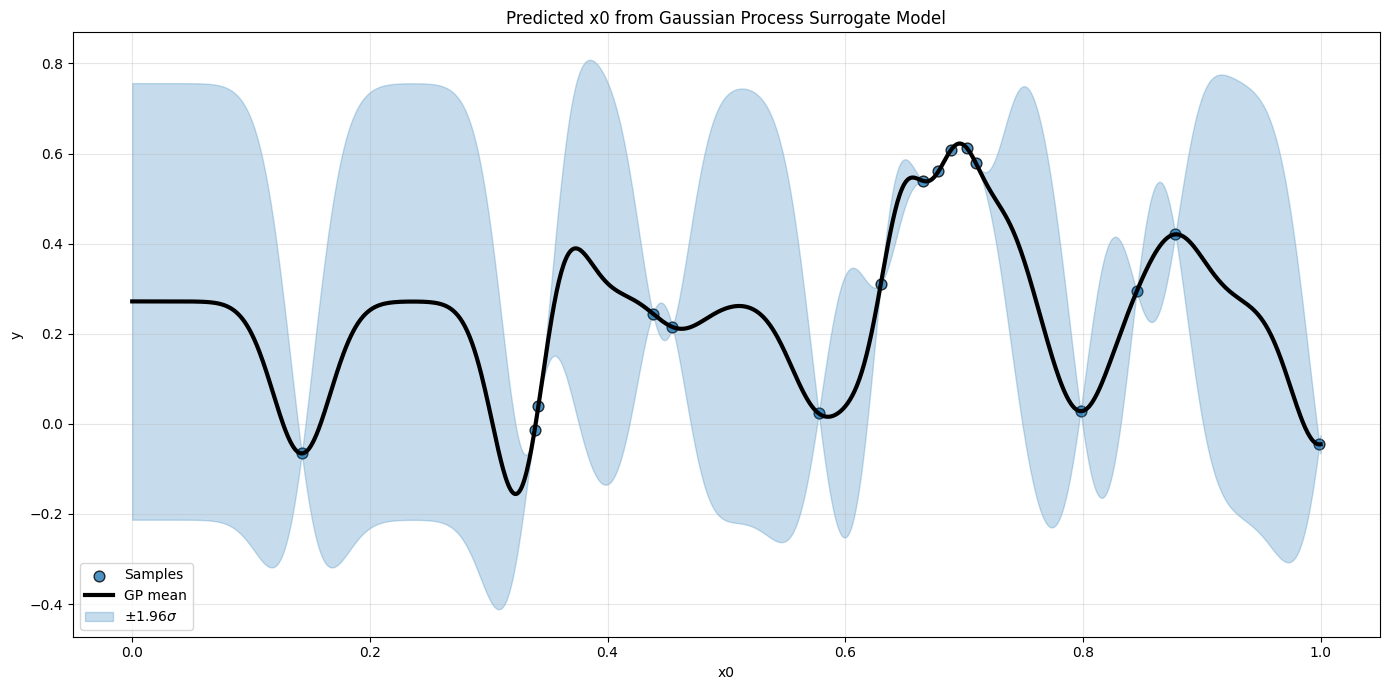

In [33]:
# Fit Gaussian Process surrogate model on x0
kernel = RBF(length_scale=[0.1], length_scale_bounds=(1e-2, 1))
model = GaussianProcessRegressor(
    kernel=kernel,
    n_restarts_optimizer=10,
    normalize_y=True,
    random_state=create_rng_seed(seed_input),
)
# Effectively assume x1 is irrelevant and project all data onto x0 axis
model.fit(X[:, 0].reshape(-1, 1), y)

length_scale = model.kernel_.length_scale
print(f"Length scale: x0 = {length_scale}")

x_pred = np.linspace(0, 1, grd_res)
y_mean, y_std = model.predict(x_pred.reshape(-1, 1), return_std=True)

# Plot predicted means and standard deviations
fig, ax = plot_1d_gp_ucb(
    x_samples=X[:, 0],
    y_samples=y,
    x_pred=x_pred,
    y_mean=y_mean,
    y_std=y_std,
    k=1.96,
    x_label="x0",
)

Projecting the observed data points onto the `x0` axis, it appears as though `x1` may have a small effect in this promising region. It would be worth querying another point in this region to investigate this.

To get a better idea of the boundaries of this region, we can train a decision tree on the data:

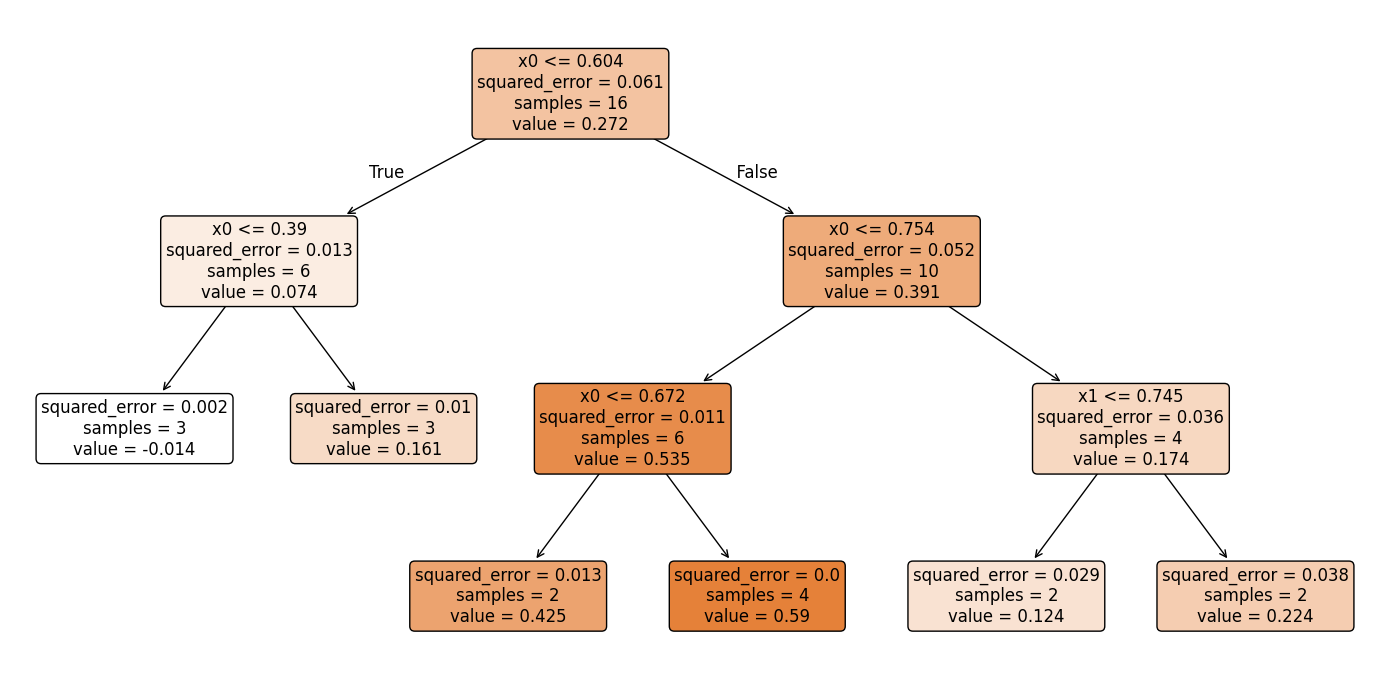

In [34]:
tree = decision_trees.get_decision_tree(
    max_depth=3, min_samples_leaf=2, seed_input=seed_input
)
tree.fit(X, y)

fig, ax = plot_decision_tree(tree=tree, n_dimensions=n_dimensions)

From the above, the two most promising regions lie in the range 0.604 < `x0` <= 0.754, with the most promising region lying in the range 0.672 < `x0` < 0.754.

However, this is just one tree, and while it can serve as a guide, it gives no information on the uncertainty in a region. In Bayesian Optimisation, it is important that the surrogate model provide an uncertainty metric that can be fed into an acquisition function.

This can be solved by training many trees instead of just one in an ensemble model. Then taking the output from each of these trees and calculating the mean and standard deviation, which can then be used to maximise an acquisition function.

An example of an ensemble is the random forest ensemble model, where each tree is formed by taking a random subset of features, finding the best possible split for each selected feature according to a metric (e.g. minimising the mean squared error), and selecting the best split among these features. This is repeated until either further splits would result in a leaf having fewer samples than the allowable minimum or the maximum depth of the tree has been reached.

We can define a grid and collate the predictions from all trees in the ensemble to calculate the mean and standard deviation at each position. Using the Upper Confidence Bound (UCB) acquisition function, we can find the next point to query:

Proposed point from random forest ensemble model = [0.701 0.373]
Number of clusters = 1


/home/chagani/projects/gitHub/AICapstoneProject_IC/src/bbo/plotting.py:207: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.tight_layout()


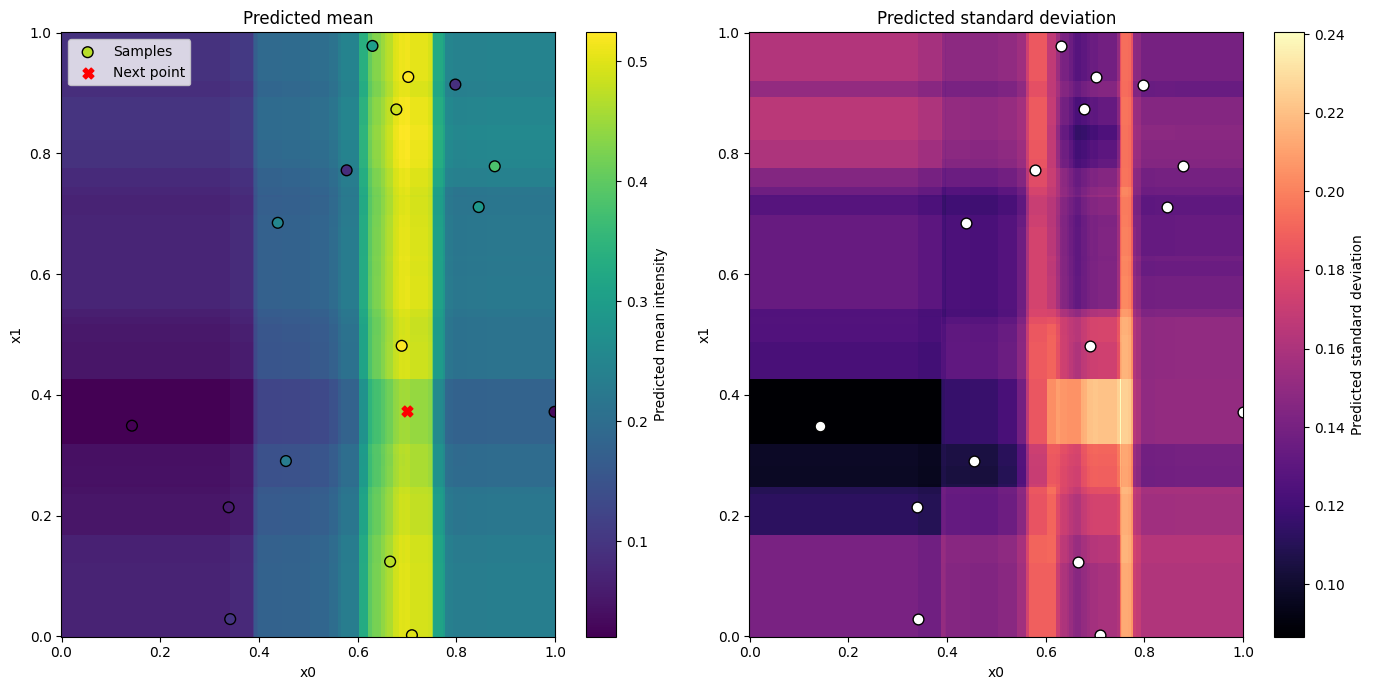

In [35]:
tree_model_params = {
    "n_estimators": 500,
    "max_depth": 3,
    "min_samples_leaf": 2,
    "seed_input": seed_input,
}

# Fit random trees ensemble model
rf = decision_trees.get_random_forests_model(**tree_model_params)
rf.fit(X, y)

# Perform grid search to evaluate model output
X0, X1 = construct_meshgrid(n_dimensions=n_dimensions, grd_res=grd_res)
X_pred = np.column_stack([X0.ravel(), X1.ravel()])
rf_mean, rf_std = decision_trees.get_ensemble_stats(rf, X_pred)
RF_mean = rf_mean.reshape(grd_res, grd_res)
RF_std = rf_std.reshape(grd_res, grd_res)

# Extract best candidates from grid as those where Upper Confidence Bound (UCB)
# function is at maximum value and calculate centroid to find proposed point.
acq_func = acquisition.ucb(rf_mean, rf_std, k=1.96)
mask = np.isclose(acq_func, acq_func.max(), rtol=1e-6, atol=1e-9)
best_candidates = X_pred[mask]
x_next = best_candidates.mean(axis=0)
print(f"Proposed point from random forest ensemble model = {x_next}")

# Use agglomerative clusterer to indicate whether best candidates are
# concentrated in a region or far apart
clusterer = get_agglomerative_clusterer(n_dimensions=n_dimensions)
labels = clusterer.fit_predict(best_candidates)
print(f"Number of clusters = {len(np.unique(labels))}")

# Plot predicted means and standard deviations
fig, axs = plot_2d_gp_surfaces(
    X0=X0,
    X1=X1,
    Y_mean=RF_mean,
    Y_std=RF_std,
    x_samples=X,
    y_samples=y,
    contour=False,
    x_next=x_next,
)

It is possible for some points to maximise the acquisition function, the mean position of these points becomes the centre of this iteration.

However, this only makes sense if the points that maximise the acquisition function lie in the same region. If they lie on opposite sides of the global space, the mean point may not be useful as it is unlikely to lie in a promising region. We can determine this using a clustering algorithm. As we do not know how many clusters we are going to see, we can adopt bottom-up hierarchical clustering, or in other words agglomerative clustering. This is where every point starts off as a cluster, and are merged in order of closest distance. We can implement a distance cutoff to act as a threshold above which clusters will not be merged. A good choice for such a threshold would be half the typical Euclidean distance between points.

As we only see evidence of one cluster above, we can safely say that the proposed point lies in a promising region.

Random forests are not the ensembling technique we can employ. Rather than finding the best splits for each feature according to a metric, in the extra trees (or extremely randomised trees) ensemble model, the split thresholds are chosen at random. When using this ensemble model, we find a proposed point that lies quite close to an observed data point:

Proposed point from extra trees ensemble model = [0.704 0.104]
Number of clusters = 1


/home/chagani/projects/gitHub/AICapstoneProject_IC/src/bbo/plotting.py:207: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.tight_layout()


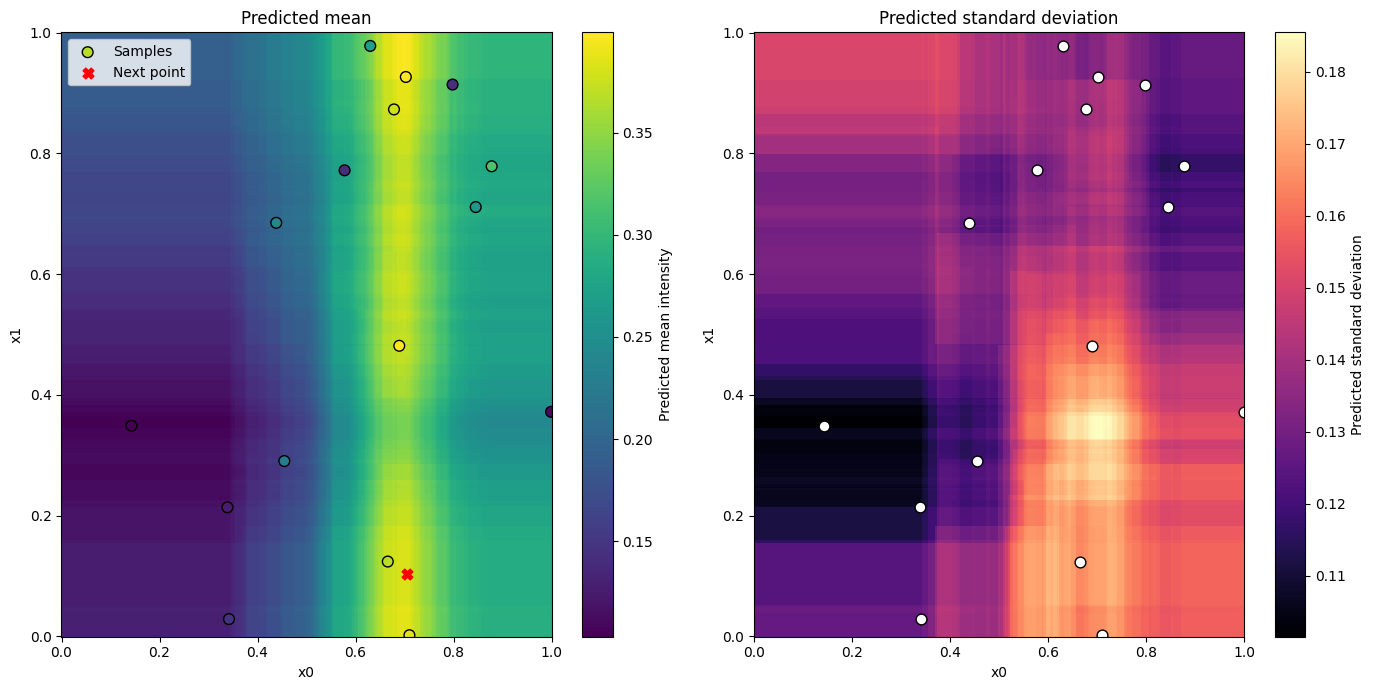

In [36]:
# Fit extremely randomised trees ensemble model
et = decision_trees.get_extra_trees_model(**tree_model_params)
et.fit(X, y)

# Perform grid search to evaluate model output
X0, X1 = construct_meshgrid(n_dimensions=n_dimensions, grd_res=grd_res)
X_pred = np.column_stack([X0.ravel(), X1.ravel()])
et_mean, et_std = decision_trees.get_ensemble_stats(et, X_pred)
ET_mean = et_mean.reshape(grd_res, grd_res)
ET_std = et_std.reshape(grd_res, grd_res)

# Extract best candidates from grid as those where Upper Confidence Bound (UCB)
# function is at maximum value and calculate centroid to find proposed point.
acq_func = acquisition.ucb(et_mean, et_std, k=1.96)
mask = np.isclose(acq_func, acq_func.max(), rtol=1e-6, atol=1e-9)
best_candidates = X_pred[mask]
x_next = best_candidates.mean(axis=0)
print(f"Proposed point from extra trees ensemble model = {x_next}")

# Use agglomerative clusterer to indicate whether best candidates are
# concentrated in a region or far apart
clusterer = get_agglomerative_clusterer(n_dimensions=n_dimensions)
labels = clusterer.fit_predict(best_candidates)
print(f"Number of clusters = {len(np.unique(labels))}")

# Plot predicted means and standard deviations
fig, axs = plot_2d_gp_surfaces(
    X0=X0,
    X1=X1,
    Y_mean=ET_mean,
    Y_std=ET_std,
    x_samples=X,
    y_samples=y,
    contour=False,
    x_next=x_next,
)

Of the two points that have been proposed, the one from the random trees ensemble model is selected for this week's query as it lies father from an observed data point. It also lies in a region where the model is least certain, making it a good test point. We can perform a grid search as we did above, although this does not improve the resolution:

In [37]:
x_next = grid_search_mean(
    model=rf, acq_func=acquisition.ucb, k=1.96, n_dimensions=2, grd_res=grd_res
)
print(f"Proposed point using Upper Confidence Bound (k = 1.96) acquisition function on random forests ensemble model = {x_next}")

Proposed point using Upper Confidence Bound (k = 1.96) acquisition function on random forests ensemble model = [0.701 0.373]


When selecting this week's query, I mistakenly extracted one of the grid points that maximised the acquisition function rather than the mean. Therefore, I submitted the point (0.6975, 0.368). This lies very close to the proposed point above and lies in this uncertain but promising region, so should not make too much difference to the analysis.

## Week 8 - Exploring a promising region

In [38]:
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF

from bbo import acquisition, decision_trees
from bbo.bayesian_optimisation import get_reg_model
from bbo.clustering import get_agglomerative_clusterer
from bbo.data import get_current_weeks_points
from bbo.plotting import plot_1d_gp_ucb, plot_2d_gp_surfaces, plot_decision_tree
from bbo.random import create_rng_seed
from bbo.utils import construct_meshgrid

seed_input = "function 2"  # input string to create random seed
n_dimensions = 2  # number of features
grd_res = 1001  # axis resolution

In [39]:
X, y = get_current_weeks_points(function_id=2, week=8)

print(f"Last week's query {X[-1]} yields {y[-1]}")

Last week's query [0.6975 0.368 ] yields 0.5226899210845681


Although last week's query yields a lower output than the previous week's, it is still high and indicates that the region is very promising.

Length scales: x0 = 0.04308724498270142, x1 = 0.3345052348055261


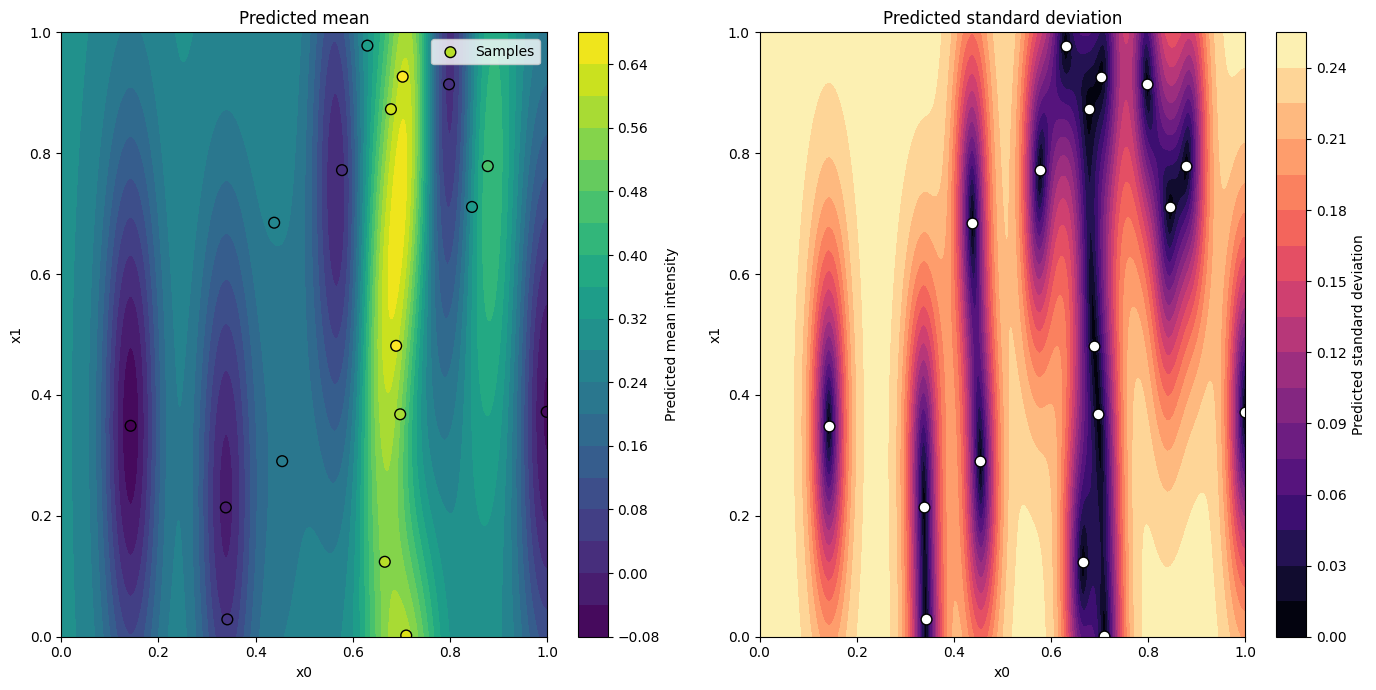

In [40]:
# Fit Gaussian Process surrogate model on known data
model = get_reg_model(
    n_dimensions=2, seed_input=seed_input, length_scale_bounds=(1e-2, 10)
)
model.fit(X, y)

length_scales = model.kernel_.length_scale
print(f"Length scales: x0 = {length_scales[0]}, x1 = {length_scales[1]}")

# Perform grid search to evaluate model output
X0, X1 = construct_meshgrid(n_dimensions=n_dimensions, grd_res=grd_res)
X_pred = np.column_stack([X0.ravel(), X1.ravel()])
y_mean, y_std = model.predict(X_pred, return_std=True)
Y_mean = y_mean.reshape(grd_res, grd_res)
Y_std = y_std.reshape(grd_res, grd_res)

# Plot predicted means and standard deviations
fig, axs = plot_2d_gp_surfaces(
    X0=X0, X1=X1, Y_mean=Y_mean, Y_std=Y_std, x_samples=X, y_samples=y
)

The length scale for `x1` from the Gaussian Process surrogate model has decreased by almost an order of magnitude, implying that this feature is not as smooth as we had initially thought.

Additionally, two promising regions appear to have developed within the promising `x0` range identified over the last few weeks.

/home/chagani/projects/gitHub/AICapstoneProject_IC/.venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


Length scale: x0 = 0.010000000000000004


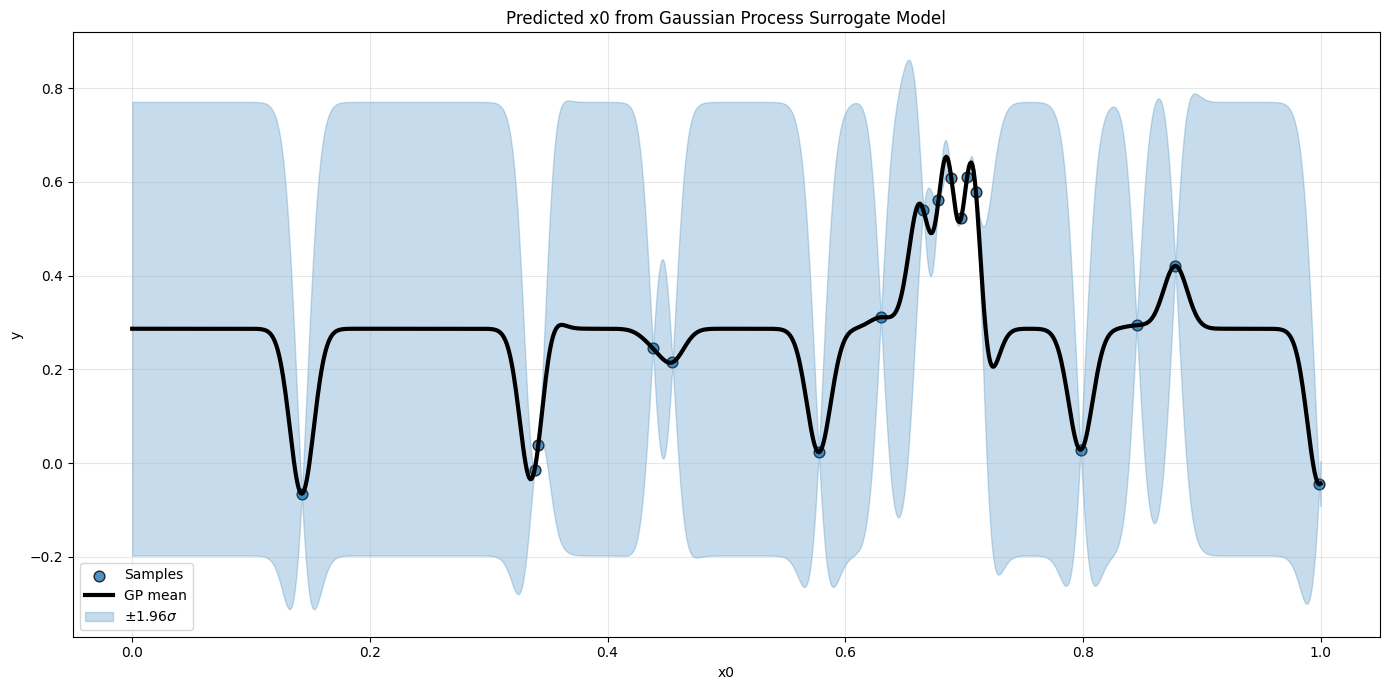

In [41]:
# Fit Gaussian Process surrogate model on x0
kernel = RBF(length_scale=[0.1], length_scale_bounds=(1e-2, 1))
model = GaussianProcessRegressor(
    kernel=kernel,
    n_restarts_optimizer=10,
    normalize_y=True,
    random_state=create_rng_seed(seed_input),
)
# Effectively assume x1 is irrelevant and project all data onto x0 axis
model.fit(X[:, 0].reshape(-1, 1), y)

length_scale = model.kernel_.length_scale
print(f"Length scale: x0 = {length_scale}")

x_pred = np.linspace(0, 1, grd_res)
y_mean, y_std = model.predict(x_pred.reshape(-1, 1), return_std=True)

# Plot predicted means and standard deviations
fig, ax = plot_1d_gp_ucb(
    x_samples=X[:, 0],
    y_samples=y,
    x_pred=x_pred,
    y_mean=y_mean,
    y_std=y_std,
    k=1.96,
    x_label="x0",
)

Projecting the data points onto the `x0` axis shows that the narrow range that looked promising has some structure. While we have a limited query budget, we still have not mapped out this region and it seems to be worth investigating.

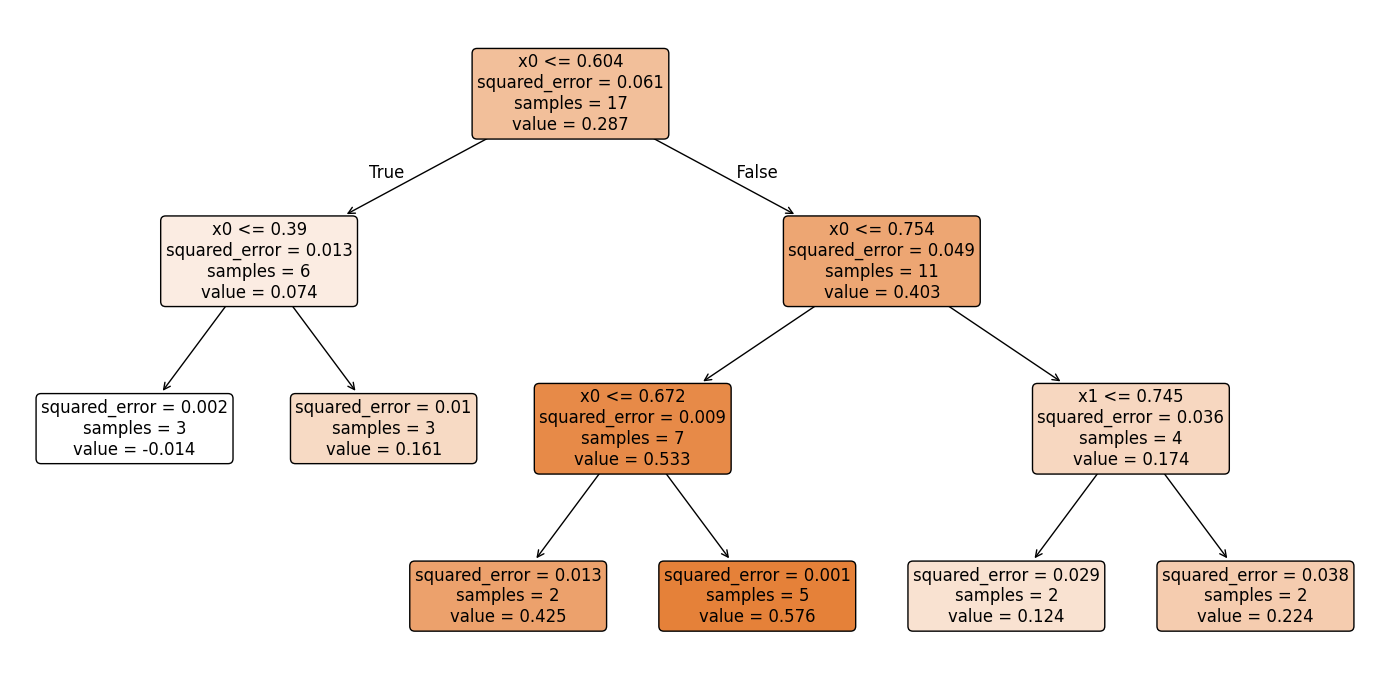

In [42]:
tree = decision_trees.get_decision_tree(
    max_depth=3, min_samples_leaf=2, seed_input=seed_input
)
tree.fit(X, y)

fig, ax = plot_decision_tree(tree=tree, n_dimensions=n_dimensions)

There is little change in the decision tree. The two most promising areas still lie in the range 0.604 < x0 <= 0.754, with the most promising region lying in the range 0.672 < x0 < 0.754. The hyperparameters maximum tree depth and minimium leaf node samples seem fine to use in the ensemble models.

Proposed point from random forest ensemble model = [0.749  0.4255]
Number of clusters = 1


/home/chagani/projects/gitHub/AICapstoneProject_IC/src/bbo/plotting.py:207: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.tight_layout()


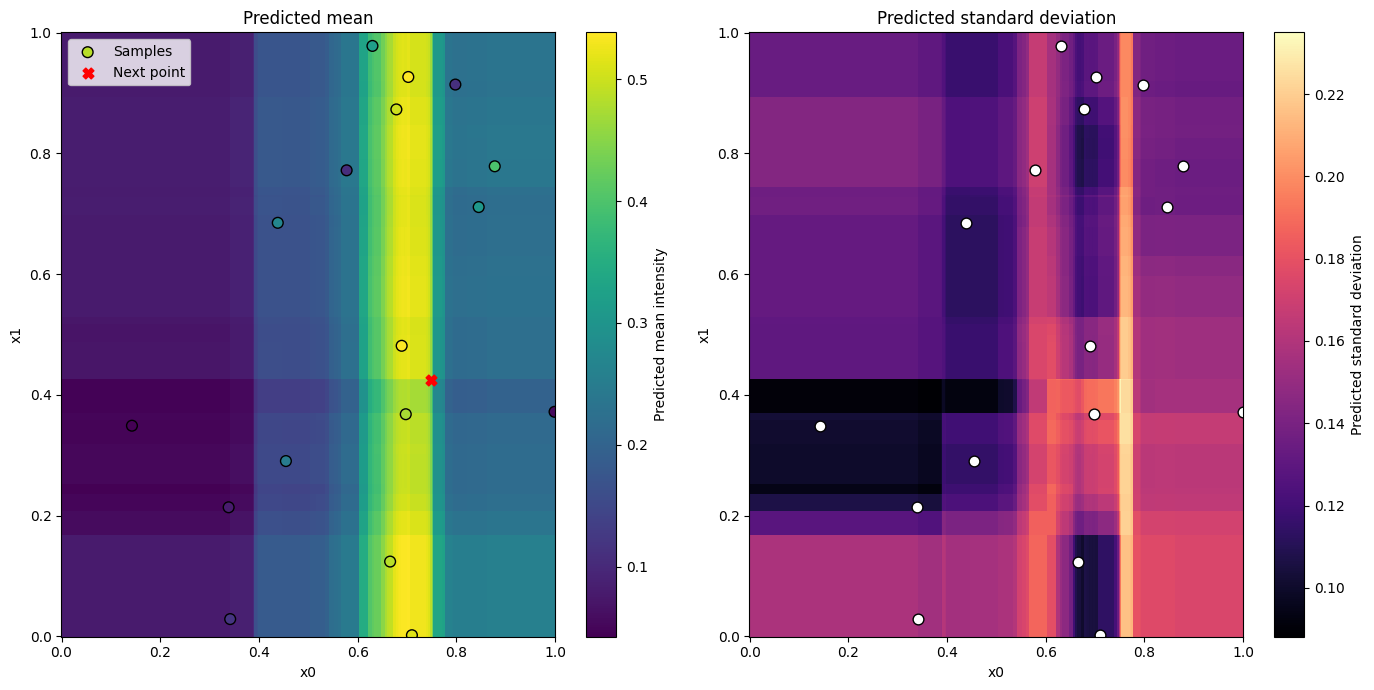

In [43]:
tree_model_params = {
    "n_estimators": 500,
    "max_depth": 3,
    "min_samples_leaf": 2,
    "seed_input": seed_input,
}

# Fit random trees ensemble model
rf = decision_trees.get_random_forests_model(**tree_model_params)
rf.fit(X, y)

# Perform grid search to evaluate model output
X0, X1 = construct_meshgrid(n_dimensions=n_dimensions, grd_res=grd_res)
X_pred = np.column_stack([X0.ravel(), X1.ravel()])
rf_mean, rf_std = decision_trees.get_ensemble_stats(rf, X_pred)
RF_mean = rf_mean.reshape(grd_res, grd_res)
RF_std = rf_std.reshape(grd_res, grd_res)

# Extract best candidates from grid as those where Upper Confidence Bound (UCB)
# function is at maximum value and calculate centroid to find proposed point.
acq_func = acquisition.ucb(rf_mean, rf_std, k=1.96)
mask = np.isclose(acq_func, acq_func.max(), rtol=1e-6, atol=1e-9)
best_candidates = X_pred[mask]
x_next = best_candidates.mean(axis=0)
print(f"Proposed point from random forest ensemble model = {x_next}")

# Use agglomerative clusterer to indicate whether best candidates are
# concentrated in a region or far apart
clusterer = get_agglomerative_clusterer(n_dimensions=n_dimensions)
labels = clusterer.fit_predict(best_candidates)
print(f"Number of clusters = {len(np.unique(labels))}")

# Plot predicted means and standard deviations
fig, axs = plot_2d_gp_surfaces(
    X0=X0,
    X1=X1,
    Y_mean=RF_mean,
    Y_std=RF_std,
    x_samples=X,
    y_samples=y,
    contour=False,
    x_next=x_next,
)

Proposed point from extra trees ensemble model = [0.6355 0.104 ]
Number of clusters = 1


/home/chagani/projects/gitHub/AICapstoneProject_IC/src/bbo/plotting.py:207: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.tight_layout()


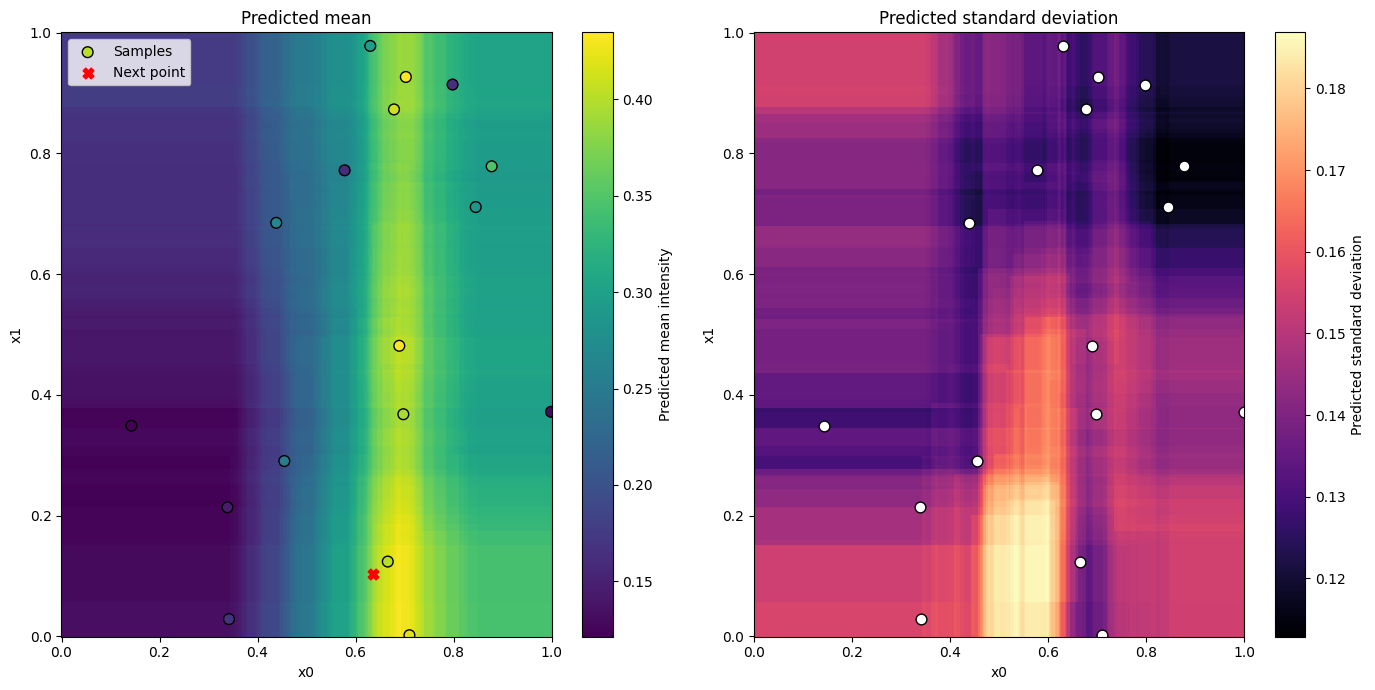

In [44]:
# Fit extremely randomised trees ensemble model
et = decision_trees.get_extra_trees_model(**tree_model_params)
et.fit(X, y)

# Perform grid search to evaluate model output
X0, X1 = construct_meshgrid(n_dimensions=n_dimensions, grd_res=grd_res)
X_pred = np.column_stack([X0.ravel(), X1.ravel()])
et_mean, et_std = decision_trees.get_ensemble_stats(et, X_pred)
ET_mean = et_mean.reshape(grd_res, grd_res)
ET_std = et_std.reshape(grd_res, grd_res)

# Extract best candidates from grid as those where Upper Confidence Bound (UCB)
# function is at maximum value and calculate centroid to find proposed point.
acq_func = acquisition.ucb(et_mean, et_std, k=1.96)
mask = np.isclose(acq_func, acq_func.max(), rtol=1e-6, atol=1e-9)
best_candidates = X_pred[mask]
x_next = best_candidates.mean(axis=0)
print(f"Proposed point from extra trees ensemble model = {x_next}")

# Use agglomerative clusterer to indicate whether best candidates are
# concentrated in a region or far apart
clusterer = get_agglomerative_clusterer(n_dimensions=n_dimensions)
labels = clusterer.fit_predict(best_candidates)
print(f"Number of clusters = {len(np.unique(labels))}")

# Plot predicted means and standard deviations
fig, axs = plot_2d_gp_surfaces(
    X0=X0,
    X1=X1,
    Y_mean=ET_mean,
    Y_std=ET_std,
    x_samples=X,
    y_samples=y,
    contour=False,
    x_next=x_next,
)

Both the random forest and extra trees ensemble models suggest points that do not lie in the region at higher `x1`, which looks very promising according to the Gaussian Process surrogate model. This region does not have any observed data points, so it would be worth querying here given its promise.

We can divide the phase space in regions according to the leaf nodes in the decision tree. We can then find the midpoint in `x0` between the ranges in that dimension for the region with the highest value. When choosing the `x1` coordinate, we can find the midpoint between the largest gap in this dimension within the promising `x0` range:

In [45]:
# Get leaf nodes and ranges, and sort by value (mean)
regions = decision_trees.get_regions(tree, n_dimensions)
sorted_regions = sorted(regions, key=lambda x: x[2], reverse=True)

# Extract x0 dimension boundaries from leaf that yields best mean
x0_min = sorted_regions[0][0][0]
x0_max = sorted_regions[0][1][0]

# Find x1 coordinate that lies in centre of largest gap between points in this
# dimension
x_aoi_idx = np.where((X[:, 0] > x0_min) & (X[:, 0] <= x0_max))
x1_aoi_sorted = np.sort(X[x_aoi_idx][:, 1])
diff = np.diff(x1_aoi_sorted)
largest_gap_idx = np.argmax(diff)
midpoint_x1 = (x1_aoi_sorted[largest_gap_idx] + x1_aoi_sorted[largest_gap_idx + 1]) / 2

# Proposed point is midpoint of region in x0 and centre of largest gap between
# points in x1
x_next = np.array([(x0_max + x0_min) / 2, midpoint_x1])
print(f"Proposed point that lies within most promising region = {x_next}")

Proposed point that lies within most promising region = [0.71305664 0.6770885 ]


## Week 9 - A new maximum!

In [46]:
import numpy as np

from bbo import acquisition, decision_trees
from bbo.bayesian_optimisation import get_reg_model
from bbo.data import get_current_weeks_points
from bbo.plotting import plot_2d_gp_surfaces, plot_decision_tree
from bbo.random import create_rng_seed
from bbo.utils import construct_meshgrid

seed_input = "function 2"  # input string to create random seed
n_dimensions = 2  # number of features
grd_res = 1001  # axis resolution

In [47]:
X, y = get_current_weeks_points(function_id=2, week=9)

print(f"Last week's query {X[-1]} yields {y[-1]}")

Last week's query [0.71305  0.677089] yields 0.6178287184243787


Last week's query gives us a new maximum output, albeit a relatively small increase.

It appears as though there are at least two peaks within the narrow band in `x0` identified earlier. As we have more data points, we can increase the maximum depth of the decision tree from 3 to 4 to try to find a boundary between these two regions:

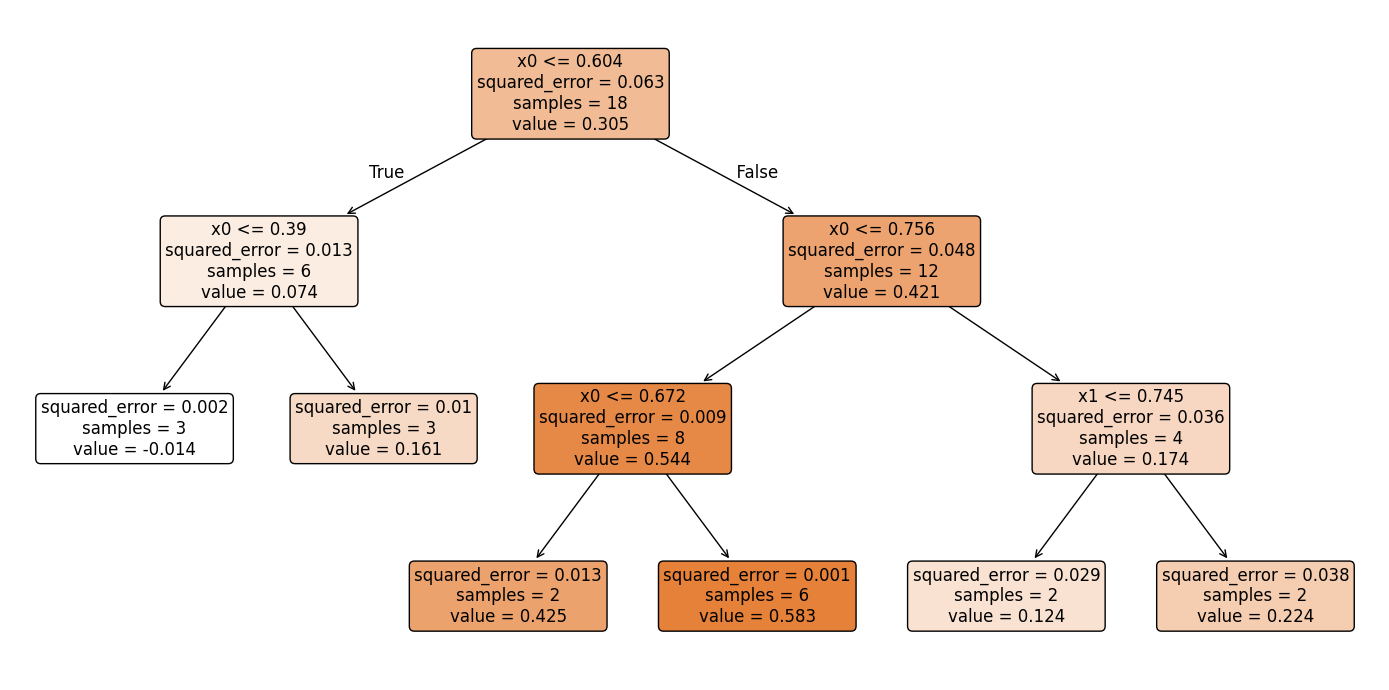

In [48]:
tree = decision_trees.get_decision_tree(
    max_depth=3, min_samples_leaf=2, seed_input=seed_input
)
tree.fit(X, y)

fig, ax = plot_decision_tree(tree=tree, n_dimensions=n_dimensions)

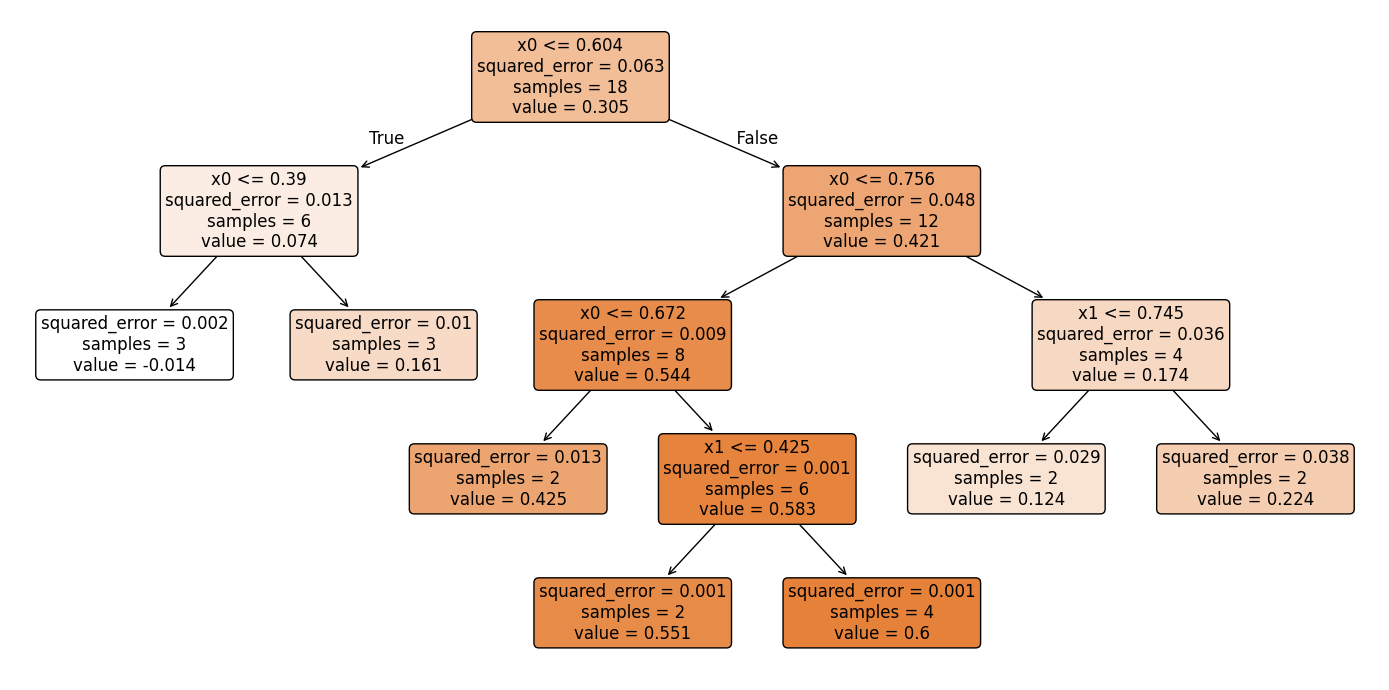

In [49]:
tree = decision_trees.get_decision_tree(
    max_depth=4, min_samples_leaf=2, seed_input=seed_input
)
tree.fit(X, y)

fig, ax = plot_decision_tree(tree=tree, n_dimensions=n_dimensions)

The model suggests that the boundary lies at `x1` = 0.425. We can train a random forests ensemble model on the deeper tree depth, and use the Upper Confidence Bound (UCB) acquisition function to find a point to query next:

Proposed point from random forest ensemble model = [0.749  0.4255]
Number of clusters = 1


/home/chagani/projects/gitHub/AICapstoneProject_IC/src/bbo/plotting.py:207: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.tight_layout()


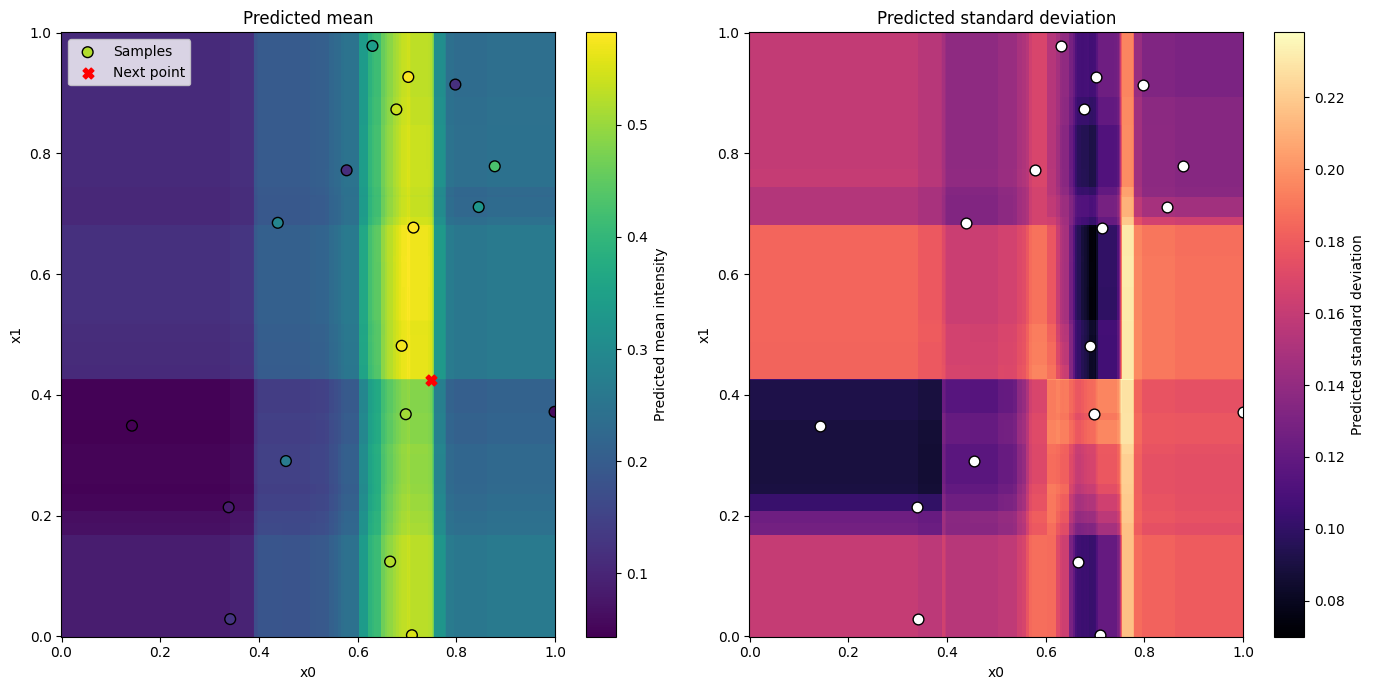

In [50]:
tree_model_params = {
    "n_estimators": 500,
    "max_depth": 4,
    "min_samples_leaf": 2,
    "seed_input": seed_input,
}

# Fit random trees ensemble model
rf = decision_trees.get_random_forests_model(**tree_model_params)
rf.fit(X, y)

# Perform grid search to evaluate model output
X0, X1 = construct_meshgrid(n_dimensions=n_dimensions, grd_res=grd_res)
X_pred = np.column_stack([X0.ravel(), X1.ravel()])
rf_mean, rf_std = decision_trees.get_ensemble_stats(rf, X_pred)
RF_mean = rf_mean.reshape(grd_res, grd_res)
RF_std = rf_std.reshape(grd_res, grd_res)

# Extract best candidates from grid as those where Upper Confidence Bound (UCB)
# function is at maximum value and calculate centroid to find proposed point.
acq_func = acquisition.ucb(rf_mean, rf_std, k=1.96)
mask = np.isclose(acq_func, acq_func.max(), rtol=1e-6, atol=1e-9)
best_candidates = X_pred[mask]
x_next = best_candidates.mean(axis=0)
print(f"Proposed point from random forest ensemble model = {x_next}")

# Use agglomerative clusterer to indicate whether best candidates are
# concentrated in a region or far apart
clusterer = get_agglomerative_clusterer(n_dimensions=n_dimensions)
labels = clusterer.fit_predict(best_candidates)
print(f"Number of clusters = {len(np.unique(labels))}")

# Plot predicted means and standard deviations
fig, axs = plot_2d_gp_surfaces(
    X0=X0,
    X1=X1,
    Y_mean=RF_mean,
    Y_std=RF_std,
    x_samples=X,
    y_samples=y,
    contour=False,
    x_next=x_next,
)

The point suggested actually lies very close to the `x1` boundary identified above, and at the upper edge of the promising band in `x0`.

While that could be an interesting area to investigate, another option is to query a point within the region with the highest value as identifed by the decision tree. This is the region where 0.672 < `x0` <= 0.756 and `x1` > 0.425. This would combine the search for a new maximum in the most promising region with an increased understanding of the landscape, which may show that the region can be divided further.

In [51]:
# Location of top 5 points
sorted_idx = np.argsort(y)[:-6:-1]
for idx in sorted_idx:
    print(f"X = {X[idx]}, y = {y[idx]}")

X = [0.71305  0.677089], y = 0.6178287184243787
X = [0.70263656 0.9265642 ], y = 0.6112052157614438
X = [0.689216 0.481342], y = 0.6086974926214477
X = [0.709956 0.002   ], y = 0.57860251197845
X = [0.678471 0.872835], y = 0.5604928662282773


The three points with the highest output lie in this region. The centroid of these points may be an interesting point to investigate:

In [52]:
centroid_top_3 = np.mean(X[sorted_idx[:3]], axis=0)
print(f"Proposed point as centroid of best 3 observed points = {centroid_top_3}")

min_dist = np.min(np.linalg.norm(X - centroid_top_3, axis=1))
print(f"Minimum distance of centroid from nearest neighbour = {min_dist}")

Proposed point as centroid of best 3 observed points = [0.70163419 0.6949984 ]
Minimum distance of centroid from nearest neighbour = 0.021238347311481658


The proposed point lies very close to an observed data point and therefore may not provide much information on the nature of the landscape.

In [53]:
centroid_top_2 = np.mean(X[sorted_idx[:2]], axis=0)
print(f"Proposed point as centroid of best 2 observed points = {centroid_top_2}")

min_dist = np.min(np.linalg.norm(X - centroid_top_2, axis=1))
print(f"Minimum distance of centroid from nearest neighbour = {min_dist}")

Proposed point as centroid of best 2 observed points = [0.70784328 0.8018266 ]
Minimum distance of centroid from nearest neighbour = 0.07684350191726201


The centroid of the two points with the highest output looks more promising.

## Week 10 - Investigating the other promising region

In [54]:
import matplotlib.pyplot as plt
import numpy as np

from bbo import acquisition, decision_trees
from bbo.bayesian_optimisation import get_reg_model
from bbo.data import get_current_weeks_points
from bbo.plotting import plot_2d_gp_surfaces
from bbo.random import create_rng_seed
from bbo.utils import construct_meshgrid

seed_input = "function 2"  # input string to create random seed
n_dimensions = 2  # number of features
grd_res = 1001  # axis resolution

In [55]:
X, y = get_current_weeks_points(function_id=2, week=10)

print(f"Last week's query {X[-1]} yields {y[-1]}")

Last week's query [0.707843 0.801827] yields 0.5765931390394705


Last week's query yields a relatively high output value but is lower than the two best observed points. It would imply that `x1` has some structure in this region, with the potential for three maxima.

Length scales: x0 = 0.014574599868537092, x1 = 1.046177950946


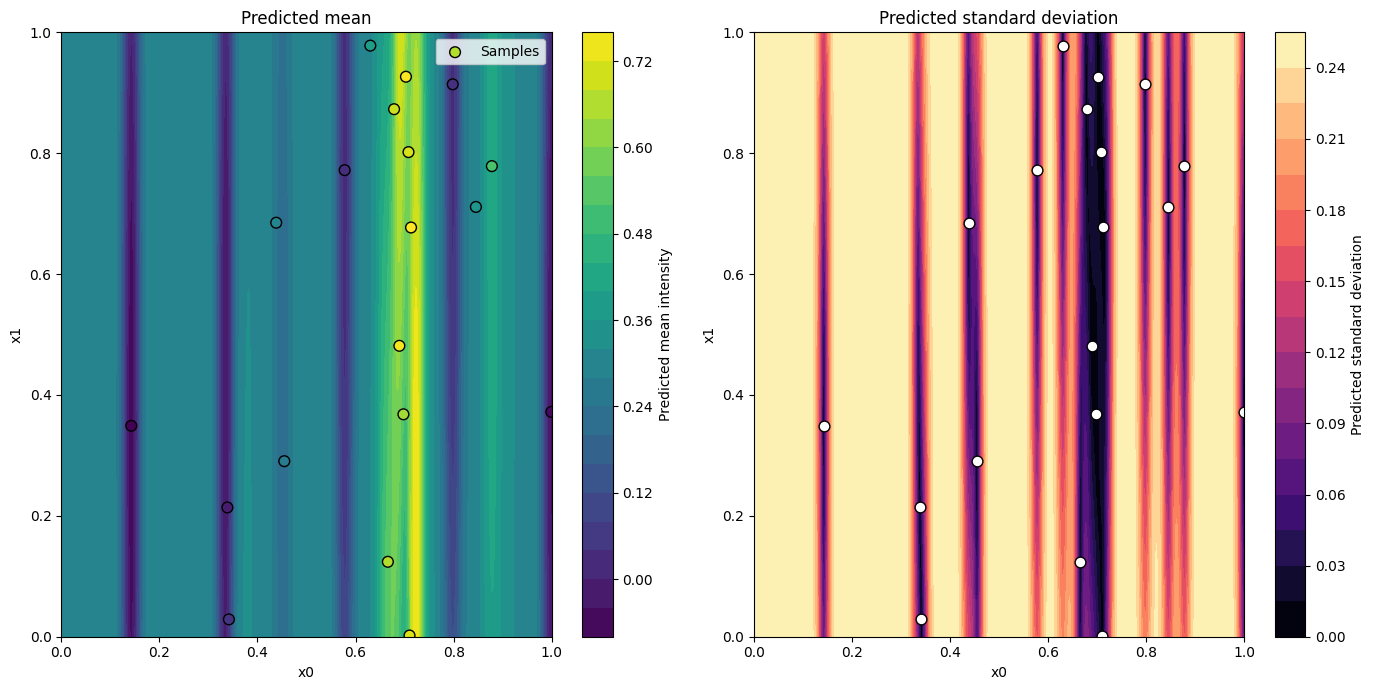

In [56]:
# Fit Gaussian Process surrogate model on known data
model = get_reg_model(
    n_dimensions=2, seed_input=seed_input, length_scale_bounds=(1e-2, 10)
)
model.fit(X, y)

length_scales = model.kernel_.length_scale
print(f"Length scales: x0 = {length_scales[0]}, x1 = {length_scales[1]}")

# Perform grid search to evaluate model output
X0, X1 = construct_meshgrid(n_dimensions=n_dimensions, grd_res=grd_res)
X_pred = np.column_stack([X0.ravel(), X1.ravel()])
y_mean, y_std = model.predict(X_pred, return_std=True)
Y_mean = y_mean.reshape(grd_res, grd_res)
Y_std = y_std.reshape(grd_res, grd_res)

# Plot predicted means and standard deviations
fig, axs = plot_2d_gp_surfaces(
    X0=X0, X1=X1, Y_mean=Y_mean, Y_std=Y_std, x_samples=X, y_samples=y
)

The Gassian Process surrogate model has divided the promising region into two bands. This should not be read into too deeply as there are not enough data points to reach this conclusion, and the model may also be underestimating the contribution of `x1` to the output.

The decision tree model has identified two promising regions separated by a boundary in `x1`. We have been exploring the most promising region, but there is not much between them when we look at their values. We can dedicate some time to exploring the second best region by slicing through the middle in the `x1` dimension and predicting the output with the Gaussian Process surrogate model as we vary `x0` within the boundaries:

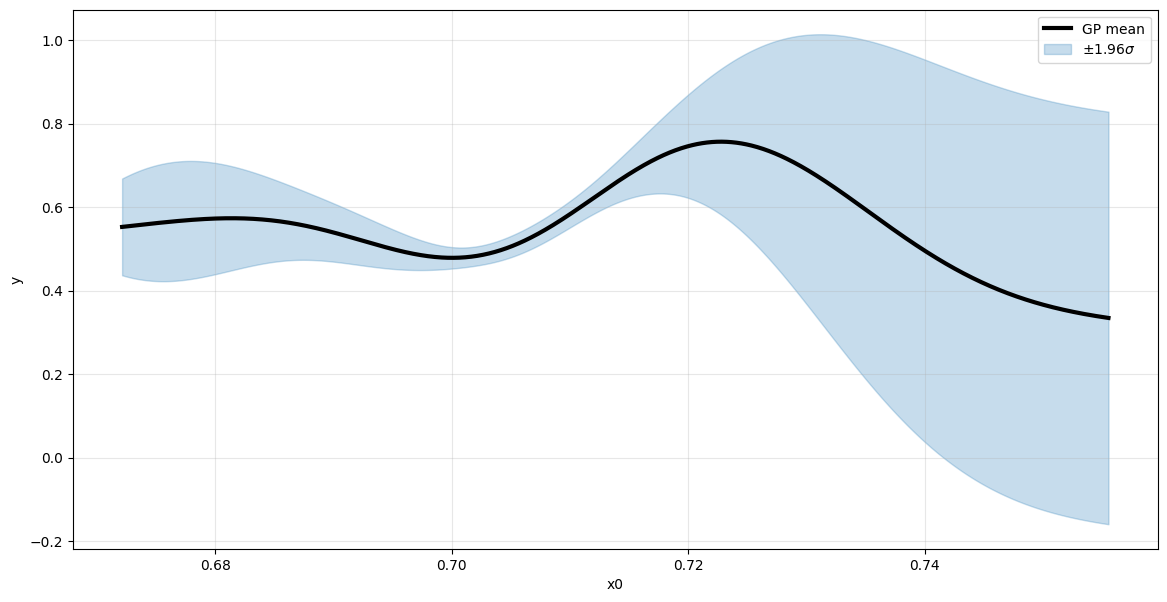

In [57]:
tree = decision_trees.get_decision_tree(
    max_depth=4, min_samples_leaf=2, seed_input=seed_input
)
tree.fit(X, y)

# Get leaf nodes and ranges, and sort by value (mean)
regions = decision_trees.get_regions(tree, n_dimensions)
sorted_regions = sorted(regions, key=lambda x: x[2], reverse=True)

# Extract x0 dimension boundaries from leaf that yields best mean
x0_min = sorted_regions[0][0][0]
x0_max = sorted_regions[0][1][0]

# Extract lower x1 dimension boundary from leaf that yields best mean. This
# should be the same as the upper boundary from leaf that yields second best
# mean.
x1_bound = sorted_regions[0][0][1]

# Slice through middle of second best region
fine_x0 = np.linspace(x0_min, x0_max, grd_res)
midpoint_x1 = x1_bound / 2
fine_x_pred = np.column_stack([fine_x0, np.full_like(fine_x0, midpoint_x1)])
fine_y_mean, fine_y_std = model.predict(fine_x_pred, return_std=True)

fig, ax = plt.subplots(1, 1, figsize=(14, 7))
ax.plot(fine_x_pred[:, 0], fine_y_mean, color="k", lw=3, label="GP mean")
ax.fill_between(
    fine_x_pred[:, 0],
    fine_y_mean - 1.96 * fine_y_std,
    fine_y_mean + 1.96 * fine_y_std,
    color="C0",
    alpha=0.25,
    label=r"$\pm 1.96\sigma$",
)
ax.grid(alpha=0.3)
ax.set_xlabel("x0")
ax.set_ylabel("y")
ax.legend()

We can use the Upper Confidence Bound (UCB) acqusition function to find the next query:

In [58]:
# Maximise UCB acquisition function to find next query
acq = acquisition.ucb(fine_y_mean, fine_y_std, k=1.96)
candidate_idx = np.argmax(acq)
x_next = fine_x_pred[candidate_idx]
print(f"Proposed point using Upper Confidence Bound (k = 1.96) = {x_next}")

Proposed point using Upper Confidence Bound (k = 1.96) = [0.7311752 0.2123355]


## Week 11 - Mapping out the best region

In [59]:
import numpy as np

from bbo import acquisition, decision_trees
from bbo.bayesian_optimisation import get_reg_model
from bbo.data import get_current_weeks_points
from bbo.enums import KernelType
from bbo.plotting import plot_2d_gp_surfaces
from bbo.random import create_rng_seed
from bbo.utils import construct_meshgrid, grid_search

seed_input = "function 2"  # input string to create random seed
n_dimensions = 2  # number of features
grd_res = 1001  # axis resolution

In [60]:
X, y = get_current_weeks_points(function_id=2, week=11)

print(f"Last week's query {X[-1]} yields {y[-1]}")

Last week's query [0.731147 0.21235 ] yields 0.45097619116194637


The output from last week's query is lower, indicating that the boundary in the `x1` dimension between the two regions may lie at a lower `x1` than previously thought.

Length scales: x0 = 0.06169329115988547, x1 = 0.25237224599950947


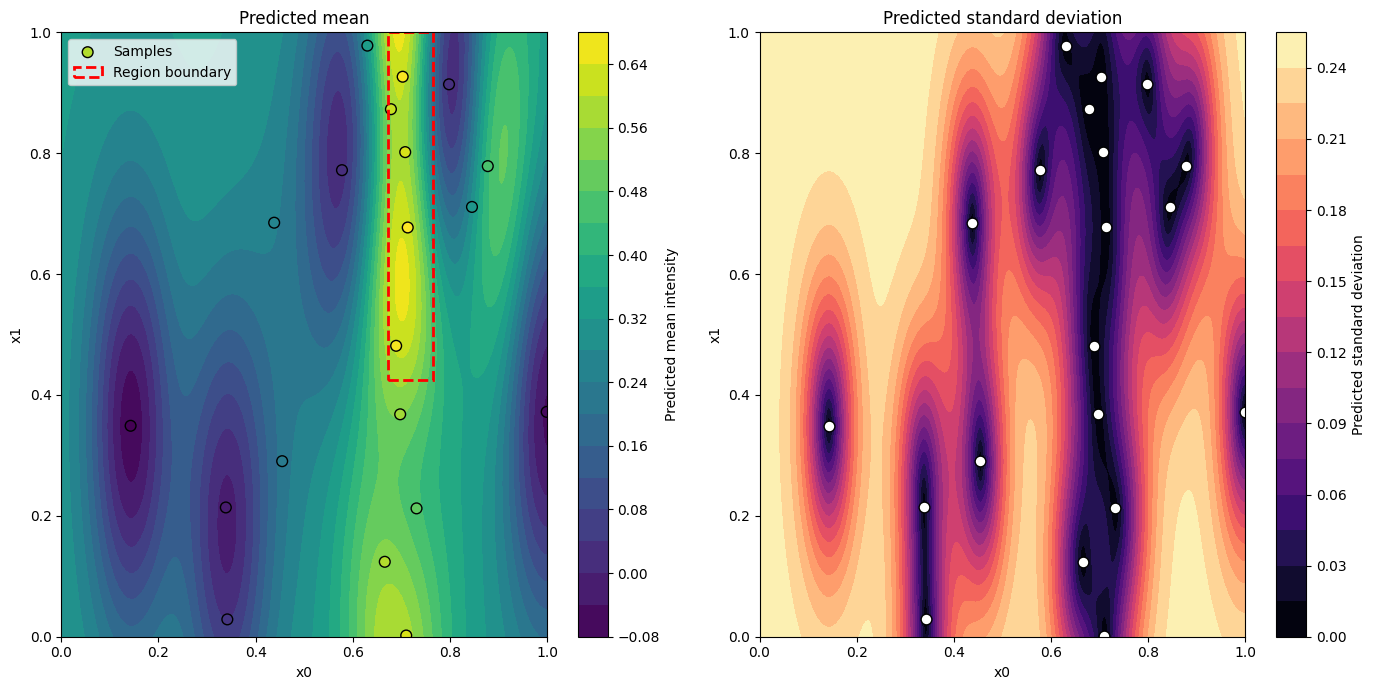

In [61]:
# Use decision tree model to define regions
tree = decision_trees.get_decision_tree(
    max_depth=4, min_samples_leaf=2, seed_input=seed_input
)
tree.fit(X, y)

# Get leaf nodes and ranges, and sort by value (mean) to get region with
# highest value
regions = decision_trees.get_regions(tree, n_dimensions)
best_region = sorted(regions, key=lambda x: x[2], reverse=True)[0]

# Fit Gaussian Process surrogate model with RBF kernel on known data
model = get_reg_model(
    n_dimensions=2, seed_input=seed_input, length_scale_bounds=(1e-2, 10)
)
model.fit(X, y)

length_scales = model.kernel_.length_scale
print(f"Length scales: x0 = {length_scales[0]}, x1 = {length_scales[1]}")

# Perform grid search to evaluate model output
X0, X1 = construct_meshgrid(n_dimensions=n_dimensions, grd_res=grd_res)
X_pred = np.column_stack([X0.ravel(), X1.ravel()])
y_mean, y_std = model.predict(X_pred, return_std=True)
Y_mean = y_mean.reshape(grd_res, grd_res)
Y_std = y_std.reshape(grd_res, grd_res)

# Plot predicted means and standard deviations
fig, axs = plot_2d_gp_surfaces(
    X0=X0,
    X1=X1,
    Y_mean=Y_mean,
    Y_std=Y_std,
    x_samples=X,
    y_samples=y,
    regions=[best_region],
)

The best region identified by the decision tree model is outlined by the dashed red line above.

As the region may be quite jagged, it may be worth using a Matern kernel. We can perform the fit globally, and then use the acquisition function to find a point within this region to query next.

Length scales: x0 = 0.03182880849184607, x1 = 2.2553120537592886


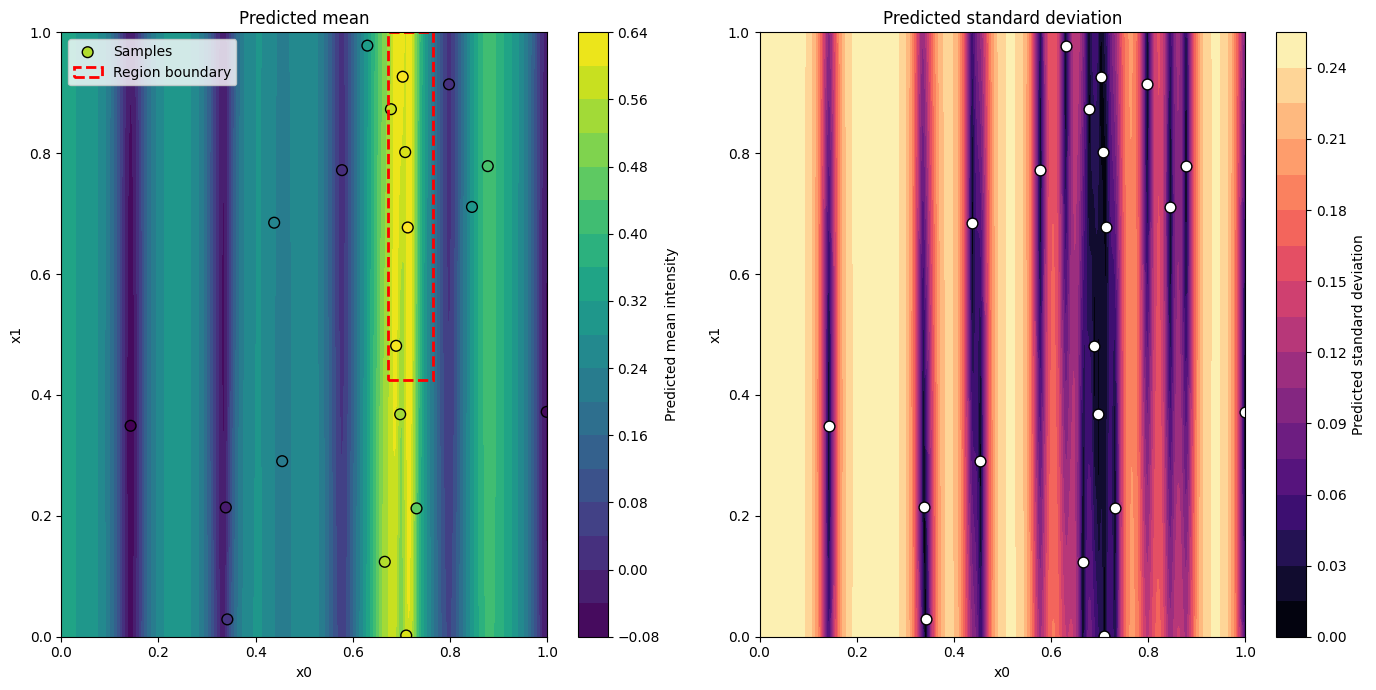

In [62]:
# Fit Gaussian Process surrogate model with Matern kernel on known data
model = get_reg_model(
    n_dimensions=2,
    seed_input=seed_input,
    kernel_type=KernelType.MATERN,
    length_scale_bounds=(1e-2, 10),
    nu=1.5,
)
model.fit(X, y)

length_scales = model.kernel_.length_scale
print(f"Length scales: x0 = {length_scales[0]}, x1 = {length_scales[1]}")

# Perform grid search to evaluate model output
y_mean, y_std = model.predict(X_pred, return_std=True)
Y_mean = y_mean.reshape(grd_res, grd_res)
Y_std = y_std.reshape(grd_res, grd_res)

# Plot predicted means and standard deviations
fig, axs = plot_2d_gp_surfaces(
    X0=X0,
    X1=X1,
    Y_mean=Y_mean,
    Y_std=Y_std,
    x_samples=X,
    y_samples=y,
    regions=[best_region],
)

In [63]:
# Reformat region boundaries
best_region_bounds = [
    (b_min, b_max) for b_min, b_max in zip(best_region[0], best_region[1])
]
y_max = y.max()

# Cycle through acquisition functions
for acq in acquisition.get_acquisition_functions(y_max=y_max, k=1.96, xi=0.1):
    x_next = grid_search(
        model,
        n_dimensions=n_dimensions,
        grd_res=grd_res,
        bounds=best_region_bounds,
        **acq["acq_kwargs"],
    )
    print(f"Proposed point using {acq['name']} acquisition function = {x_next}")
    print(f"Distance between proposed point and nearest neighbour = {np.min(np.linalg.norm(X - x_next, axis=1))}\n")

Proposed point using Upper Confidence Bound (k = 1.96) acquisition function = [0.6910972 1.       ]
Distance between proposed point and nearest neighbour = 0.06493741916612947

Proposed point using Probability of Improvement acquisition function = [0.71307448 0.67665416]
Distance between proposed point and nearest neighbour = 0.0004355264743066395

Proposed point using Expected Improvement (xi = 0.1) acquisition function = [0.69109631 1.        ]
Distance between proposed point and nearest neighbour = 0.06493658068433002



The Upper Confidence Bound (UCB) and Expected Improvement (EI) acquisition functions suggest the same point. The point suggested by the Probability of Improvement (PI) acquisition function lies closer to an observed point, and therefore is unlikely to yield any new information. Therefore, even though it lies on the upper `x1` boundary, we should query the point suggested by the UCB and EI acquisition functions.

## Week 12 - Analysing each region

In [64]:
import matplotlib.pyplot as plt
import numpy as np

from bbo import acquisition, decision_trees
from bbo.bayesian_optimisation import get_reg_model
from bbo.data import get_current_weeks_points
from bbo.enums import KernelType
from bbo.plotting import (
    plot_2d_gp_surfaces,
    plot_2d_gp_acq_func_surface,
    plot_decision_tree,
)
from bbo.random import create_rng_seed, sample_regions
from bbo.utils import construct_meshgrid, find_best_candidates

seed_input = "function 2"  # input string to create random seed
n_dimensions = 2  # number of features
grd_res = 1001  # axis resolution
n_samples = 2000  # number of candidates to generate
temperature = 0.7  # sharpness parameter for softmax distribution (lower values concentrate samples in more promising regions)

In [65]:
X, y = get_current_weeks_points(function_id=2, week=12)

print(f"Last week's query {X[-1]} yields {y[-1]}")

Last week's query [0.691096 1.      ] yields 0.5374359420797041


Last week's query returns an output that is high, but is shy of the current maximum.

Given that we have two queries left, rather than explore any new regions (such as where `x0` = 0.9), we should look to exploit what we have already. It looks like the region around `x0` = 0.7 is quite complicated, and most points would be strong candidates for the next query.

We are using the decision tree model to define regions rather than make any predictions. Therefore, we can increment the maximum tree depth to increase the number of regions. Then we can randomly generate candidates in each region. Greater proportions of candidates are generated in higher value regions according to a softmax function with a temperature parameter to control the function's sharpness. We can then extract the most promising points from each region and choose one of them for the next query.

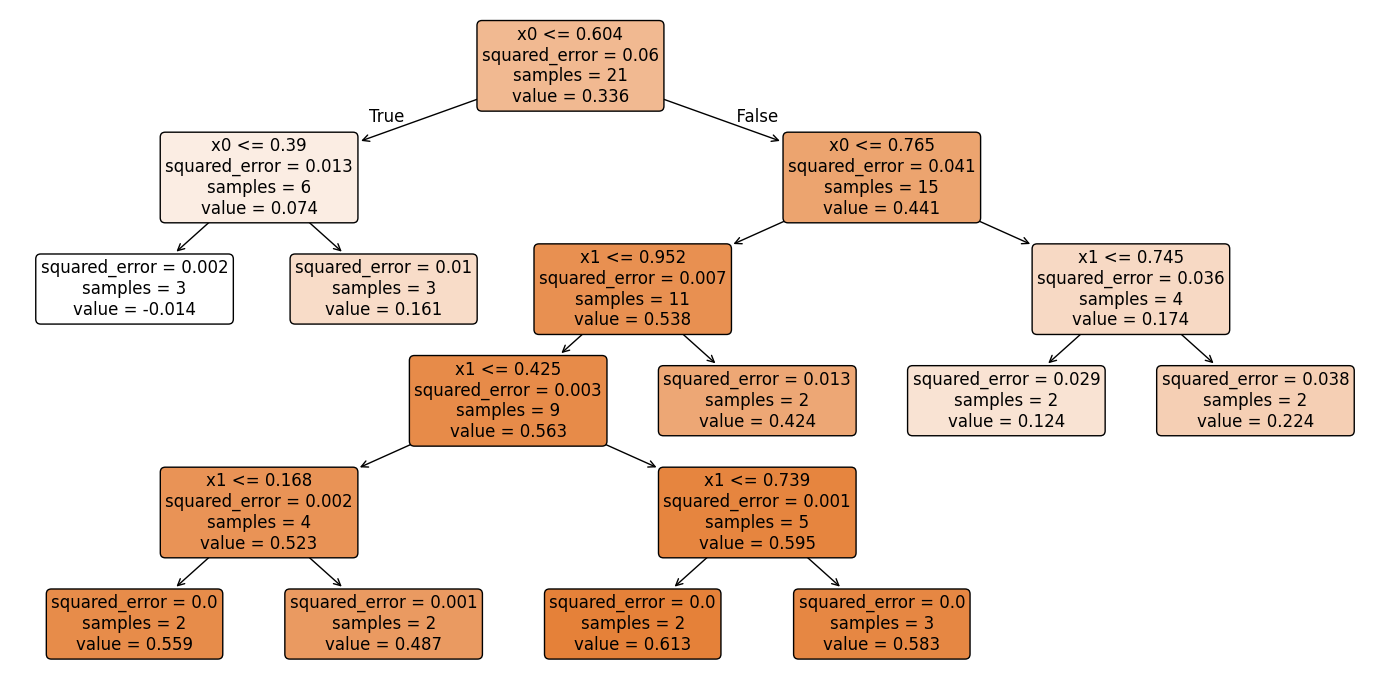

In [66]:
# Use decision tree model to define regions
tree = decision_trees.get_decision_tree(
    max_depth=5, min_samples_leaf=2, seed_input=seed_input
)
tree.fit(X, y)

# Get leaf nodes and ranges
regions = decision_trees.get_regions(tree, n_dimensions)

fig, ax = plot_decision_tree(tree=tree, n_dimensions=n_dimensions)

/home/chagani/projects/gitHub/AICapstoneProject_IC/.venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 1 of parameter length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


Proposed point in each region in order of descending acquisition function value:


/home/chagani/projects/gitHub/AICapstoneProject_IC/src/bbo/plotting.py:295: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.tight_layout()


Kernel: RBF (length scales: x0 = 0.010702243193355089, x1 = 0.794504286665144):
Region ID = 3, point = [0.71875772 0.23982925], value = 0.08178246548155976
Region ID = 2, point = [0.71912489 0.07996335], value = 0.08009230319283502
Region ID = 4, point = [0.72019603 0.4952354 ], value = 0.06316935580655074
Region ID = 5, point = [0.72019603 0.78716583], value = 0.03809635328457898
Region ID = 6, point = [0.72326404 0.95240893], value = 0.03521406377279583
Region ID = 8, point = [0.8963125  0.84557979], value = 0.015219754214785428
Region ID = 7, point = [0.89362368 0.07154224], value = 0.015217378716297879
Region ID = 0, point = [0.37748343 0.2518812 ], value = 0.014157666564337645
Region ID = 1, point = [0.39008635 0.16530371], value = 0.0141528551675833
Kernel: Matern (length scales: x0 = 0.017285323002074093, x1 = 100.00000000000004):
Region ID = 2, point = [0.685167   0.11345629], value = 0.033224625001923525
Region ID = 3, point = [0.685167   0.34122635], value = 0.033174862148589

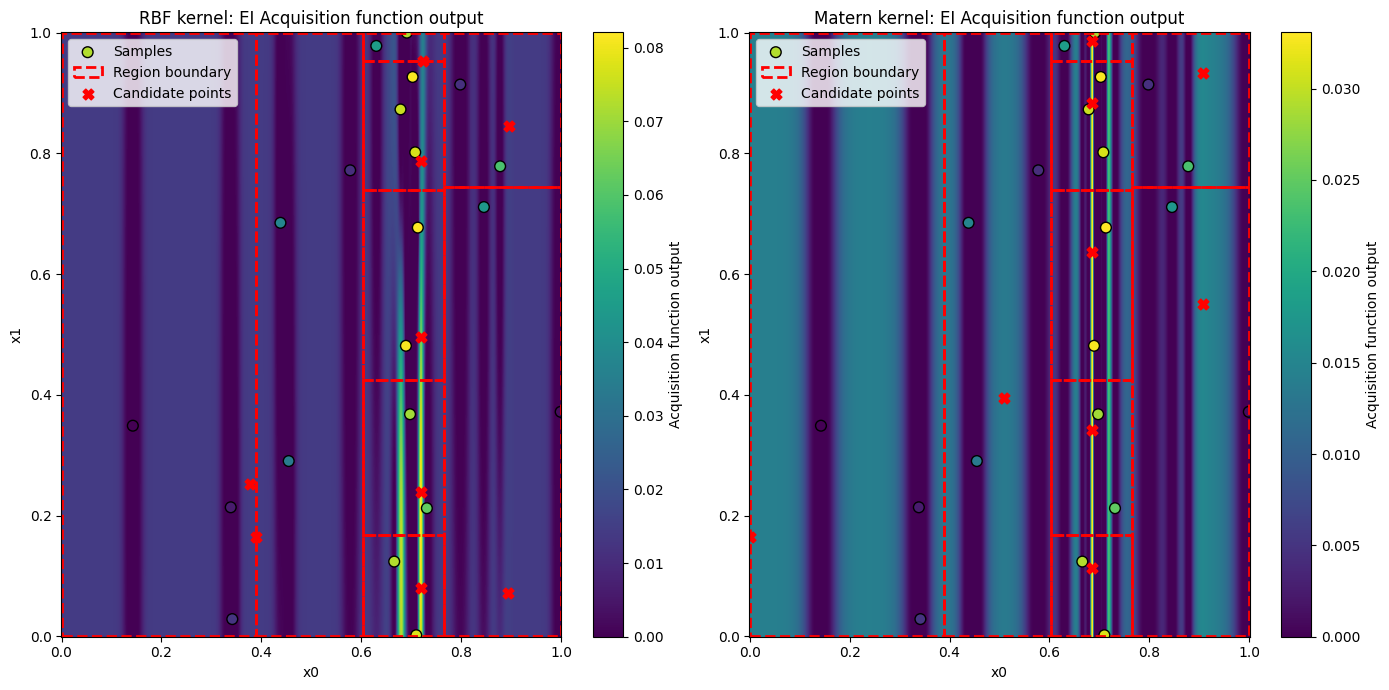

In [67]:
# Generate candidates
X_candidates, X_regions = sample_regions(
    n_samples, regions, seed_input, temperature
)

# Construct meshgrid to show output of acquisition function
X0, X1 = construct_meshgrid(n_dimensions=n_dimensions, grd_res=grd_res)
X_pred = np.column_stack([X0.ravel(), X1.ravel()])

gp_models_args = [
    {
        "kernel_type": KernelType.RBF,
    },
    {
        "kernel_type": KernelType.MATERN,
        "nu": 1.5,
    },
]
gp_models = []
gp_points = []
gp_values = []
gp_region_ids = []
gp_acqs = []

# Expected Improvement (EI) acquisition function parameters
ei_kwargs = {"y_max": y.max(), "xi": 0.01}

for model_args in gp_models_args:
    # Fit Gaussian Process surrogate model with RBF kernel on known data
    gp_model = get_reg_model(
        n_dimensions=2,
        seed_input=seed_input,
        length_scale_bounds=(1e-2, 100),
        **model_args,
        )
    gp_model.fit(X, y)
    gp_models.append(gp_model)

    # Get output from EI acquisiton function to draw grid
    gp_mean, gp_std = gp_model.predict(X_pred, return_std=True)
    gp_acq = acquisition.expect_improv(gp_mean, gp_std, **ei_kwargs)
    gp_acqs.append(gp_acq.reshape(X0.shape))

    # Use EI to assess candidates
    points, values, region_ids = find_best_candidates(
        gp_model=gp_model,
        X_candidates=X_candidates,
        X_regions=X_regions,
        acq_func=acquisition.expect_improv,
        **ei_kwargs,
    )
    gp_points.append(points)
    gp_values.append(values)
    gp_region_ids.append(region_ids)

fig, axs = plt.subplots(1, 2, figsize=(14, 7))
print("Proposed point in each region in order of descending acquisition function value:")
for i, kernel_type in enumerate(["RBF", "Matern"]):
    plot_2d_gp_acq_func_surface(
        X0=X0,
        X1=X1,
        Y_acq=gp_acqs[i],
        x_samples=X,
        y_samples=y,
        x_next=gp_points[i],
        regions=regions,
        title=f"{kernel_type} kernel: EI Acquisition function output",
        ax=axs[i],
    )

    x0_ls, x1_ls = gp_models[i].kernel_.length_scale
    sorted_idx = np.argsort(gp_values[i])[::-1]
    print(f"Kernel: {kernel_type} (length scales: x0 = {x0_ls}, x1 = {x1_ls}):")
    for idx in sorted_idx:
        print(f"Region ID = {gp_region_ids[i][idx]}, point = {gp_points[i][idx]}, value = {gp_values[i][idx]}")

We use the Expected Improvement (EI) acquisition function with exploration parameter xi = 0.01 as we are more interested in exploitation over exploration, but there is no clear maximum from the observed data.

The `x1` length scale from the Matern kernel hits the upper bound, but we think that `x1` has more of a contribution to the output than this implies. So, we can use the results from the RBF kernel to select a candidate. Of the points selected in each region, the point from region 2 has a comparable EI value to the point from region 3, but lies farther away from an observed data point. Therefore, it is the one we should submit in our next query:

In [68]:
region_id = 2
x_next_idx = np.where(gp_region_ids[0] == region_id)[0][0]
x_next = gp_points[0][x_next_idx]
print(f"Proposed point in region {region_id} using EI acquisition function (xi = 0.01) and RBF kernel = {x_next}")

Proposed point in region 2 using EI acquisition function (xi = 0.01) and RBF kernel = [0.71912489 0.07996335]


## Week 13 - A new maximum outside the most promising region

In [69]:
import matplotlib.pyplot as plt
import numpy as np

from bbo import acquisition, decision_trees
from bbo.bayesian_optimisation import get_reg_model
from bbo.data import get_current_weeks_points
from bbo.enums import KernelType
from bbo.plotting import (
    plot_2d_gp_surfaces,
    plot_2d_gp_acq_func_surface,
    plot_decision_tree,
)
from bbo.random import create_rng_seed, sample_regions
from bbo.utils import construct_meshgrid, find_best_candidates

seed_input = "function 2"  # input string to create random seed
n_dimensions = 2  # number of features
grd_res = 1001  # axis resolution
n_samples = 2000  # number of candidates to generate
temperature = 0.7  # sharpness parameter for softmax distribution (lower values concentrate samples in more promising regions)

In [70]:
X, y = get_current_weeks_points(function_id=2, week=13)

print(f"Last week's query {X[-1]} yields {y[-1]}")

Last week's query [0.719125 0.079963] yields 0.6921639685611828


Submitting a query in the second best region has yielded a new maximum! What this shows is that we simply do not have enough queries to map out the underlying function, and it seems to be quite complicated in the region around `x0` = 0.7. We can see how this result affects the decision tree and Gaussian Process surrogate models:

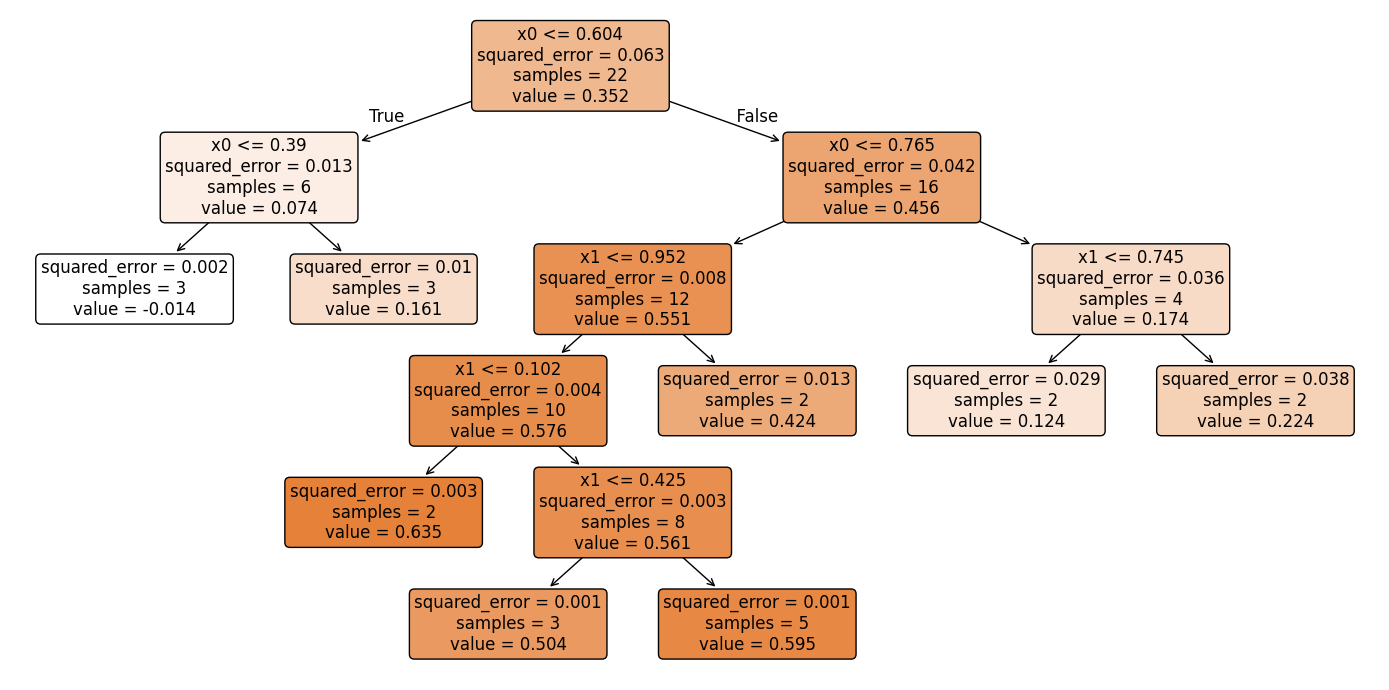

In [71]:
# Use decision tree model to define regions
tree = decision_trees.get_decision_tree(
    max_depth=5, min_samples_leaf=2, seed_input=seed_input
)
tree.fit(X, y)

# Get leaf nodes and ranges
regions = decision_trees.get_regions(tree, n_dimensions)

fig, ax = plot_decision_tree(tree=tree, n_dimensions=n_dimensions)

/home/chagani/projects/gitHub/AICapstoneProject_IC/.venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 1 of parameter length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


Proposed point in each region in order of descending acquisition function value:


/home/chagani/projects/gitHub/AICapstoneProject_IC/src/bbo/plotting.py:295: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.tight_layout()


Kernel: RBF (length scales: x0 = 0.010965602303330883, x1 = 0.8456607187099744):
Region ID = 2, point = [0.67845446 0.00121989], value = 0.0435983665256446
Region ID = 3, point = [0.67845446 0.1058268 ], value = 0.04148927134464822
Region ID = 4, point = [0.67845446 0.43098315], value = 0.01730765996022699
Region ID = 5, point = [0.72457913 0.99944481], value = 0.014473711315590925
Region ID = 7, point = [0.89946087 0.82301816], value = 0.009803917677588848
Region ID = 6, point = [0.89857504 0.24761091], value = 0.00980167406639694
Region ID = 0, point = [0.37748343 0.2518812 ], value = 0.009375708744565416
Region ID = 1, point = [0.39008635 0.16530371], value = 0.009372540758807908
Kernel: Matern (length scales: x0 = 0.01778805435425244, x1 = 100.00000000000004):
Region ID = 6, point = [0.91033178 0.40755975], value = 0.009810195511920514
Region ID = 7, point = [0.91033178 0.88446683], value = 0.009810195393904868
Region ID = 0, point = [0.00023433 0.16530371], value = 0.0093719974680

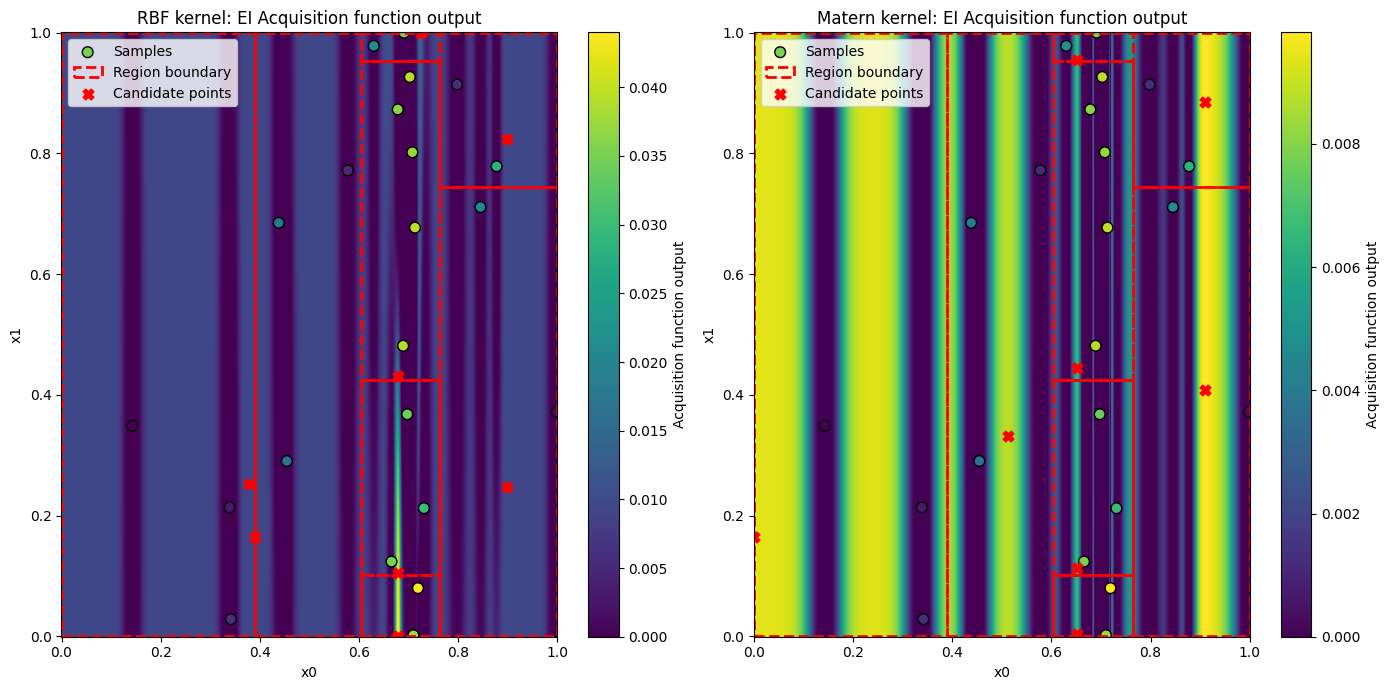

In [72]:
# Generate candidates
X_candidates, X_regions = sample_regions(
    n_samples, regions, seed_input, temperature
)

# Construct meshgrid to show output of acquisition function
X0, X1 = construct_meshgrid(n_dimensions=n_dimensions, grd_res=grd_res)
X_pred = np.column_stack([X0.ravel(), X1.ravel()])

gp_models_args = [
    {
        "kernel_type": KernelType.RBF,
    },
    {
        "kernel_type": KernelType.MATERN,
        "nu": 1.5,
    },
]
gp_models = []
gp_points = []
gp_values = []
gp_region_ids = []
gp_acqs = []

# Expected Improvement (EI) acquisition function parameters
ei_kwargs = {"y_max": y.max(), "xi": 0.01}

for model_args in gp_models_args:
    # Fit Gaussian Process surrogate model with RBF kernel on known data
    gp_model = get_reg_model(
        n_dimensions=2,
        seed_input=seed_input,
        length_scale_bounds=(1e-2, 100),
        **model_args,
        )
    gp_model.fit(X, y)
    gp_models.append(gp_model)

    # Get output from EI acquisiton function to draw grid
    gp_mean, gp_std = gp_model.predict(X_pred, return_std=True)
    gp_acq = acquisition.expect_improv(gp_mean, gp_std, **ei_kwargs)
    gp_acqs.append(gp_acq.reshape(X0.shape))

    # Use EI to assess candidates
    points, values, region_ids = find_best_candidates(
        gp_model=gp_model,
        X_candidates=X_candidates,
        X_regions=X_regions,
        acq_func=acquisition.expect_improv,
        **ei_kwargs,
    )
    gp_points.append(points)
    gp_values.append(values)
    gp_region_ids.append(region_ids)

fig, axs = plt.subplots(1, 2, figsize=(14, 7))
print("Proposed point in each region in order of descending acquisition function value:")
for i, kernel_type in enumerate(["RBF", "Matern"]):
    plot_2d_gp_acq_func_surface(
        X0=X0,
        X1=X1,
        Y_acq=gp_acqs[i],
        x_samples=X,
        y_samples=y,
        x_next=gp_points[i],
        regions=regions,
        title=f"{kernel_type} kernel: EI Acquisition function output",
        ax=axs[i],
    )

    x0_ls, x1_ls = gp_models[i].kernel_.length_scale
    sorted_idx = np.argsort(gp_values[i])[::-1]
    print(f"Kernel: {kernel_type} (length scales: x0 = {x0_ls}, x1 = {x1_ls}):")
    for idx in sorted_idx:
        print(f"Region ID = {gp_region_ids[i][idx]}, point = {gp_points[i][idx]}, value = {gp_values[i][idx]}")

The decision tree model gives us one less region than it did last week. Again, the `x1` length scale reaches its maximum limit when using the Matern kernel. Using the results from the RBF kernel, the top 2 candidates lie in similar regions as they did last week. Although not in the region of the best observed data point, the candidate in region 3 lies closest to this point. Therefore, this is the candidate we shall submit for our final query:

In [73]:
region_id = 3
x_next_idx = np.where(gp_region_ids[0] == region_id)[0][0]
x_next = gp_points[0][x_next_idx]
print(f"Proposed point in region {region_id} using EI acquisition function (xi = 0.01) and RBF kernel = {x_next}")

Proposed point in region 3 using EI acquisition function (xi = 0.01) and RBF kernel = [0.67845446 0.1058268 ]


## Final Result

In [74]:
import numpy as np

from bbo.data import get_current_weeks_points

X, y = get_current_weeks_points(function_id=2, week=14)

print(f"Last week's query {X[-1]} yields {y[-1]}")

Last week's query [0.678454 0.105827] yields 0.6006029343752469


The final query yields an output that is relatively high but does not beat the maximum found last week. The point lies very close to another neighbour:

In [75]:
# Find closest point spatially to last week's query
distances = np.linalg.norm(X[:-1] - X[-1], axis=1)
idx = np.argmin(distances)

print(f"Closest point to last week's query {X[idx]} yielded {y[idx]}")
print(f"Distance between points = {distances[idx]}")
print(f"Relative difference between outputs = {np.abs(y[idx] - y[-1]) / (y.max() - y.min())}")

Closest point to last week's query [0.66579958 0.12396913] yielded 0.5389961189269181
Distance between points = 0.022119474265724103
Relative difference between outputs = 0.08129826354711657


There is about an 8% drop from last week's query to its closest observed data point. While not a big drop, given the short distance between them, it would imply that the underlying function is quite steep in this region (a gradient of around 18%).

There appears to be a region of maxima at around `x0` = 0.7, which does not seem to be too sensitive to changes in the `x1` parameter. It also seems to be quite a complicated region with many maxima rather than one single peak.

It looks as though using the decision tree model to divide the landscape into regions and then generating candidate points in these regions to assess with a Guassian Process surrogate model and acquisition function is a reasonable method to continue to find points to query. It may be worth changing the exploration parameter on the Expected Improvement (EI) acquisition function, or trying a different acquisition function. It looks as though the landscape is quite complicated, and given the suspected jagged nature of the underlying function it could be that with more data points, the Matern kernel would provide a better fit.

At some point it would also be a good idea to explore the region where `x0` = 0.9, which unfortunately I was not able to do given the limited query budget. It would be interesting to see whether this region would end up being more promising than the region we explored here.